# Pareto Curve: Min-E2E vs Code Size

This notebook solves min-E2E compilation plans while sweeping the allowed code-size budget for every workload in a benchmark, then plots the evaluated Pareto curves.

Benchmarks covered: FFmpeg, SQLite, CoreMark, JetStream (float-mm, gcc-loops, hashset, quicksort, tsf), MiBench.

In [2]:
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if (path / "evaluation" / "compilation-plan" / "solver.py").exists():
            return path
    raise RuntimeError("Could not find the truejit repository root")


PROJECT_ROOT = find_project_root(Path.cwd())
EVAL_DIR = PROJECT_ROOT / "evaluation" / "compilation-plan"
if str(EVAL_DIR) not in sys.path:
    sys.path.insert(0, str(EVAL_DIR))

OUT_DIR = EVAL_DIR / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
from profiling import generate_profile_base, generate_static_info, get_history, get_static_info, profiles_root
from solver import Constraint, EndToEndTime, ObjectiveFunction, PlanEvaluation, Planner
import benchmarks as B

PROFILE_CSV = "profile.csv"
DEFAULT_MODE = "interpret"
SWEEP_POINTS = 12
MAX_BUDGET_BYTES = None
RECOMPUTE_RESULTS = False

# Deduplicate by (binary, workload) so shared-binary benchmarks
# (blowfish encode+decode, rijndael encode+decode) only appear once.
_seen = set()
CANDIDATE_BENCHMARKS = []
for _b in B.all_benchmarks:
    _key = frozenset((str(_b.binary), wl.name) for wl in _b.workloads)
    if _key not in _seen:
        _seen.add(_key)
        CANDIDATE_BENCHMARKS.append(_b)


def _profiles_dir(binary, workload_name=None, mode=None):
    """Compute profiles directory path without creating it (unlike profiles_root)."""
    root = Path(str(binary).replace('/benchmarks/', '/profiles/')).parent
    if workload_name is not None:
        root = root / workload_name
    if mode is not None:
        root = root / mode
    return root


def has_mode_data(binary, workload_name, mode):
    d = _profiles_dir(binary, workload_name, mode)
    return d.exists() and any(p.is_dir() for p in d.iterdir())


def workloads_with_profile(benchmark):
    return [
        wl for wl in benchmark.workloads
        if (_profiles_dir(benchmark.binary, wl.name) / PROFILE_CSV).exists()
    ]


def workloads_to_generate(benchmark):
    return [
        wl for wl in benchmark.workloads
        if has_mode_data(benchmark.binary, wl.name, 'jit')
        and has_mode_data(benchmark.binary, wl.name, 'interp')
        and not (_profiles_dir(benchmark.binary, wl.name) / PROFILE_CSV).exists()
    ]


# Generate metadata.csv for benchmarks that have raw data but haven't been
# statically analyzed yet.
for b in CANDIDATE_BENCHMARKS:
    if not b.binary.exists():
        continue
    meta = _profiles_dir(b.binary) / 'metadata.csv'
    if meta.exists():
        continue
    has_data = any(
        has_mode_data(b.binary, wl.name, 'jit') or has_mode_data(b.binary, wl.name, 'interp')
        for wl in b.workloads
    )
    if not has_data:
        continue
    print(f"{b.name}: generating metadata.csv...")
    try:
        generate_static_info(b.binary)
        print(f"{b.name}: done")
    except Exception as e:
        print(f"{b.name}: skipped — {e}")

AVAILABLE_BENCHMARKS = [
    b for b in CANDIDATE_BENCHMARKS
    if b.binary.exists()
    and (_profiles_dir(b.binary) / 'metadata.csv').exists()
    and any(
        has_mode_data(b.binary, wl.name, 'jit') or has_mode_data(b.binary, wl.name, 'interp')
        for wl in b.workloads
    )
]

for b in AVAILABLE_BENCHMARKS:
    n_ok = len(workloads_with_profile(b))
    n_gen = len(workloads_to_generate(b))
    print(f"{b.name}: {n_ok} workloads ready, {n_gen} to generate")

FFmpeg: 16 workloads ready, 0 to generate
SQLite: 9 workloads ready, 0 to generate
CoreMark: 1 workloads ready, 0 to generate
float-mm: 1 workloads ready, 0 to generate
gcc-loops: 1 workloads ready, 0 to generate
hashset: 1 workloads ready, 0 to generate
quicksort: 1 workloads ready, 0 to generate
tsf: 1 workloads ready, 0 to generate
basicmath: 1 workloads ready, 0 to generate
bitcount: 1 workloads ready, 0 to generate
stringsearch: 1 workloads ready, 0 to generate
cjpeg: 1 workloads ready, 0 to generate
djpeg: 1 workloads ready, 0 to generate
rawcaudio: 1 workloads ready, 0 to generate
rawdaudio: 1 workloads ready, 0 to generate
blowfish-encode: 1 workloads ready, 0 to generate
rijndael-encode: 1 workloads ready, 0 to generate
crc32: 1 workloads ready, 0 to generate
sha: 1 workloads ready, 0 to generate
BT: 1 workloads ready, 0 to generate
CG: 1 workloads ready, 0 to generate
EP: 1 workloads ready, 0 to generate
FT: 1 workloads ready, 0 to generate
IS: 1 workloads ready, 0 to generat

In [4]:
class EvaluatedCodeSize(ObjectiveFunction):
    """Code-size objective aligned with PlanEvaluation's final accounting."""

    priorities = ["interpret", "async", "jit", "specialize", "static"]

    def __init__(self):
        super().__init__()
        self.calculator = {
            "interpret": lambda fn: 0,
            "jit": lambda fn: self.profile.loc[fn, "size.dynamic.jit"],
            "async": lambda fn: self.profile.loc[fn, "size.dynamic.jit"],
            "specialize": lambda fn: self.profile.loc[fn, "size.dynamic.spec"],
            "static": lambda fn: self.profile.loc[fn, "size.static"] + self.profile.loc[fn, "size.dynamic.jit"],
        }


def load_profile(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    # generate_profile_base does an outer merge of jit+interp runs, leaving NaN
    # in the other run's columns for functions that appear in only one run.
    # Cross-fill so neither exec/freq column stays NaN for the LP solver.
    df["exec.jit"]        = df["exec.jit"].fillna(df["exec.interp"])
    df["exec.interp"]     = df["exec.interp"].fillna(df["exec.jit"])
    df["freq.jit"]        = df["freq.jit"].fillna(df["freq.interp"])
    df["freq.interp"]     = df["freq.interp"].fillna(df["freq.jit"])
    df["compilation.jit"] = df["compilation.jit"].fillna(0)
    df["start.jit"]       = df["start.jit"].fillna(0)
    df["start.interp"]    = df["start.interp"].fillna(0)
    df["size.dynamic.jit"] = df["size.dynamic.jit"].fillna(0)
    df["size.static"]      = df["size.static"].fillna(0)
    return df


def workload_code_size(profile: pd.DataFrame) -> int:
    return int((profile["size.static"].fillna(0) + profile["size.dynamic.jit"].fillna(0)).sum())


def make_budget_sweep(max_code_size: int, points: int = 12) -> np.ndarray:
    if max_code_size <= 0:
        return np.array([0], dtype=int)

    smallest_positive = max(1, int(max_code_size * 0.0001))
    geometric = np.geomspace(smallest_positive, max_code_size, points)
    anchors = np.array([
        0,
        4 * 1024,
        16 * 1024,
        64 * 1024,
        256 * 1024,
        1 * 1024 * 1024,
        max_code_size,
    ])
    budgets = np.unique(np.concatenate([geometric, anchors]).round().astype(int))
    budgets = budgets[(budgets >= 0) & (budgets <= max_code_size)]
    return budgets


def pareto_front(df: pd.DataFrame) -> pd.DataFrame:
    points = df.sort_values(["code_size", "e2e"]).copy()
    keep = []
    best_e2e = float("inf")
    for _, row in points.iterrows():
        if row["e2e"] < best_e2e:
            keep.append(True)
            best_e2e = row["e2e"]
        else:
            keep.append(False)
    return points.loc[keep]

In [5]:
from copy import copy as _copy

for benchmark in AVAILABLE_BENCHMARKS:
    to_gen = workloads_to_generate(benchmark)
    if not to_gen:
        print(f"{benchmark.name}: all profile.csv files present")
        continue
    print(f"{benchmark.name}: generating profile.csv for {len(to_gen)} workloads...")
    tmp = _copy(benchmark)
    tmp.workloads = to_gen
    generate_profile_base(tmp)
    print(f"{benchmark.name}: done")

# Summary across all available benchmarks
rows = []
for benchmark in AVAILABLE_BENCHMARKS:
    for wl in workloads_with_profile(benchmark):
        prof = pd.read_csv(_profiles_dir(benchmark.binary, wl.name) / PROFILE_CSV)
        max_budget = int(MAX_BUDGET_BYTES or workload_code_size(prof))
        rows.append({
            "benchmark": benchmark.name,
            "workload": wl.name,
            "touched_functions": len(prof),
            "workload_code_size_mb": round(workload_code_size(prof) / 1e6, 3),
            "n_budgets": len(make_budget_sweep(max_budget, SWEEP_POINTS)),
        })
pd.DataFrame(rows)

FFmpeg: all profile.csv files present
SQLite: all profile.csv files present
CoreMark: all profile.csv files present
float-mm: all profile.csv files present
gcc-loops: all profile.csv files present
hashset: all profile.csv files present
quicksort: all profile.csv files present
tsf: all profile.csv files present
basicmath: all profile.csv files present
bitcount: all profile.csv files present
stringsearch: all profile.csv files present
cjpeg: all profile.csv files present
djpeg: all profile.csv files present
rawcaudio: all profile.csv files present
rawdaudio: all profile.csv files present
blowfish-encode: all profile.csv files present
rijndael-encode: all profile.csv files present
crc32: all profile.csv files present
sha: all profile.csv files present
BT: all profile.csv files present
CG: all profile.csv files present
EP: all profile.csv files present
FT: all profile.csv files present
IS: all profile.csv files present
LU: all profile.csv files present
MG: all profile.csv files present
SP:

,benchmark,workload,touched_functions,workload_code_size_mb,n_budgets
0,FFmpeg,mov-to-mp4,2460,10.135,18
1,FFmpeg,mp4-to-mkv,2474,9.948,18
2,FFmpeg,mp4-to-wav,1692,5.951,18
3,FFmpeg,mp4-resize-720p,2547,10.613,18
4,FFmpeg,jpegs-to-mp4,1381,6.066,18
...,...,...,...,...,...
88,facedetection,default,451,1.189,18
89,gnuchess,default,149,0.572,17
90,mnist,default,75,0.223,16
91,snappy,default,61,0.212,16


In [6]:
def evaluate_plan(workload_name, plan, budget, label, *, static_info, workload_profiles, workload_histories):
    profile = workload_profiles[workload_name]
    history = workload_histories[workload_name]
    evaluation = PlanEvaluation(static_info, profile, plan, history)
    code_size = int(evaluation.static_code_size + evaluation.dynamic_code_size)
    return {
        "workload": workload_name,
        "label": label,
        "budget": budget,
        "code_size": code_size,
        "e2e": int(evaluation.e2e),
        "exec": int(evaluation.exec),
        "waiting": int(evaluation.waiting),
        "compilation": int(evaluation.compilation),
        "interpret": int(evaluation.interpret),
        "jit": int(evaluation.jit),
        "async": int(evaluation.async_compilation),
        "specialize": int(evaluation.specialize),
        "static": int(evaluation.static),
    }


def plan_min_e2e_at_budget(profile, budget, static_info):
    planner = Planner(
        EndToEndTime(),
        [Constraint(EvaluatedCodeSize(), upper_bound=int(budget))],
        DEFAULT_MODE,
    )
    with redirect_stdout(StringIO()):
        return planner.plan(static_info, profile)


def baseline_plan(profile, mode, static_info):
    return Planner(None, None, mode).plan(static_info, profile)


def solve_workload(workload_name, *, static_info, workload_profiles, workload_histories):
    profile = workload_profiles[workload_name]
    max_code_size = int(MAX_BUDGET_BYTES or workload_code_size(profile))
    budgets = make_budget_sweep(max_code_size, SWEEP_POINTS)

    rows = []
    for i, budget in enumerate(budgets, 1):
        print(f"  [{i:02d}/{len(budgets)}] budget={budget:,} bytes")
        plan = plan_min_e2e_at_budget(profile, int(budget), static_info)
        rows.append(evaluate_plan(workload_name, plan, int(budget), "sweep",
                                  static_info=static_info,
                                  workload_profiles=workload_profiles,
                                  workload_histories=workload_histories))

    for mode in ["interpret", "jit", "static"]:
        plan = baseline_plan(profile, mode, static_info)
        rows.append(evaluate_plan(workload_name, plan, None, mode,
                                  static_info=static_info,
                                  workload_profiles=workload_profiles,
                                  workload_histories=workload_histories))

    planner = Planner(EndToEndTime(), [], DEFAULT_MODE)
    with redirect_stdout(StringIO()):
        unbounded_plan = planner.plan(static_info, profile)
    rows.append(evaluate_plan(workload_name, unbounded_plan, None, "unbounded min-E2E",
                               static_info=static_info,
                               workload_profiles=workload_profiles,
                               workload_histories=workload_histories))
    return rows


all_results = {}

for benchmark in AVAILABLE_BENCHMARKS:
    results_csv = OUT_DIR / f"pareto-curve.{benchmark.name.lower()}-all-workloads.csv"

    if results_csv.exists() and not RECOMPUTE_RESULTS:
        print(f"[{benchmark.name}] loading cached results from {results_csv.name}")
        results = pd.read_csv(results_csv)
    else:
        workloads = workloads_with_profile(benchmark)
        static_info = get_static_info(benchmark.binary)

        wl_profiles = {
            wl.name: load_profile(_profiles_dir(benchmark.binary, wl.name) / PROFILE_CSV)
            for wl in workloads
        }
        wl_histories = {
            wl.name: get_history(benchmark.binary, wl.name, "jit")
            for wl in workloads
        }

        all_rows = []
        for i, wl in enumerate(workloads, 1):
            print(f"[{benchmark.name}] [{i:02d}/{len(workloads)}] {wl.name}")
            all_rows.extend(solve_workload(
                wl.name,
                static_info=static_info,
                workload_profiles=wl_profiles,
                workload_histories=wl_histories,
            ))

        results = pd.DataFrame(all_rows)
        results.to_csv(results_csv, index=False)
        print(f"[{benchmark.name}] saved: {results_csv.relative_to(PROJECT_ROOT)}")

    results["code_size_mb"] = results["code_size"] / 1e6
    results["e2e_s"] = results["e2e"] / 1e9
    results["budget_mb"] = results["budget"] / 1e6
    all_results[benchmark.name] = results

print("done")

[FFmpeg] loading cached results from pareto-curve.ffmpeg-all-workloads.csv
[SQLite] loading cached results from pareto-curve.sqlite-all-workloads.csv
[CoreMark] loading cached results from pareto-curve.coremark-all-workloads.csv
[float-mm] loading cached results from pareto-curve.float-mm-all-workloads.csv
[gcc-loops] loading cached results from pareto-curve.gcc-loops-all-workloads.csv
[hashset] loading cached results from pareto-curve.hashset-all-workloads.csv
[quicksort] loading cached results from pareto-curve.quicksort-all-workloads.csv
[tsf] loading cached results from pareto-curve.tsf-all-workloads.csv
[basicmath] loading cached results from pareto-curve.basicmath-all-workloads.csv
[bitcount] loading cached results from pareto-curve.bitcount-all-workloads.csv
[stringsearch] loading cached results from pareto-curve.stringsearch-all-workloads.csv
[cjpeg] loading cached results from pareto-curve.cjpeg-all-workloads.csv
[djpeg] loading cached results from pareto-curve.djpeg-all-workl

saved: evaluation/compilation-plan/out/pareto-curve.ffmpeg-all-workloads.pdf


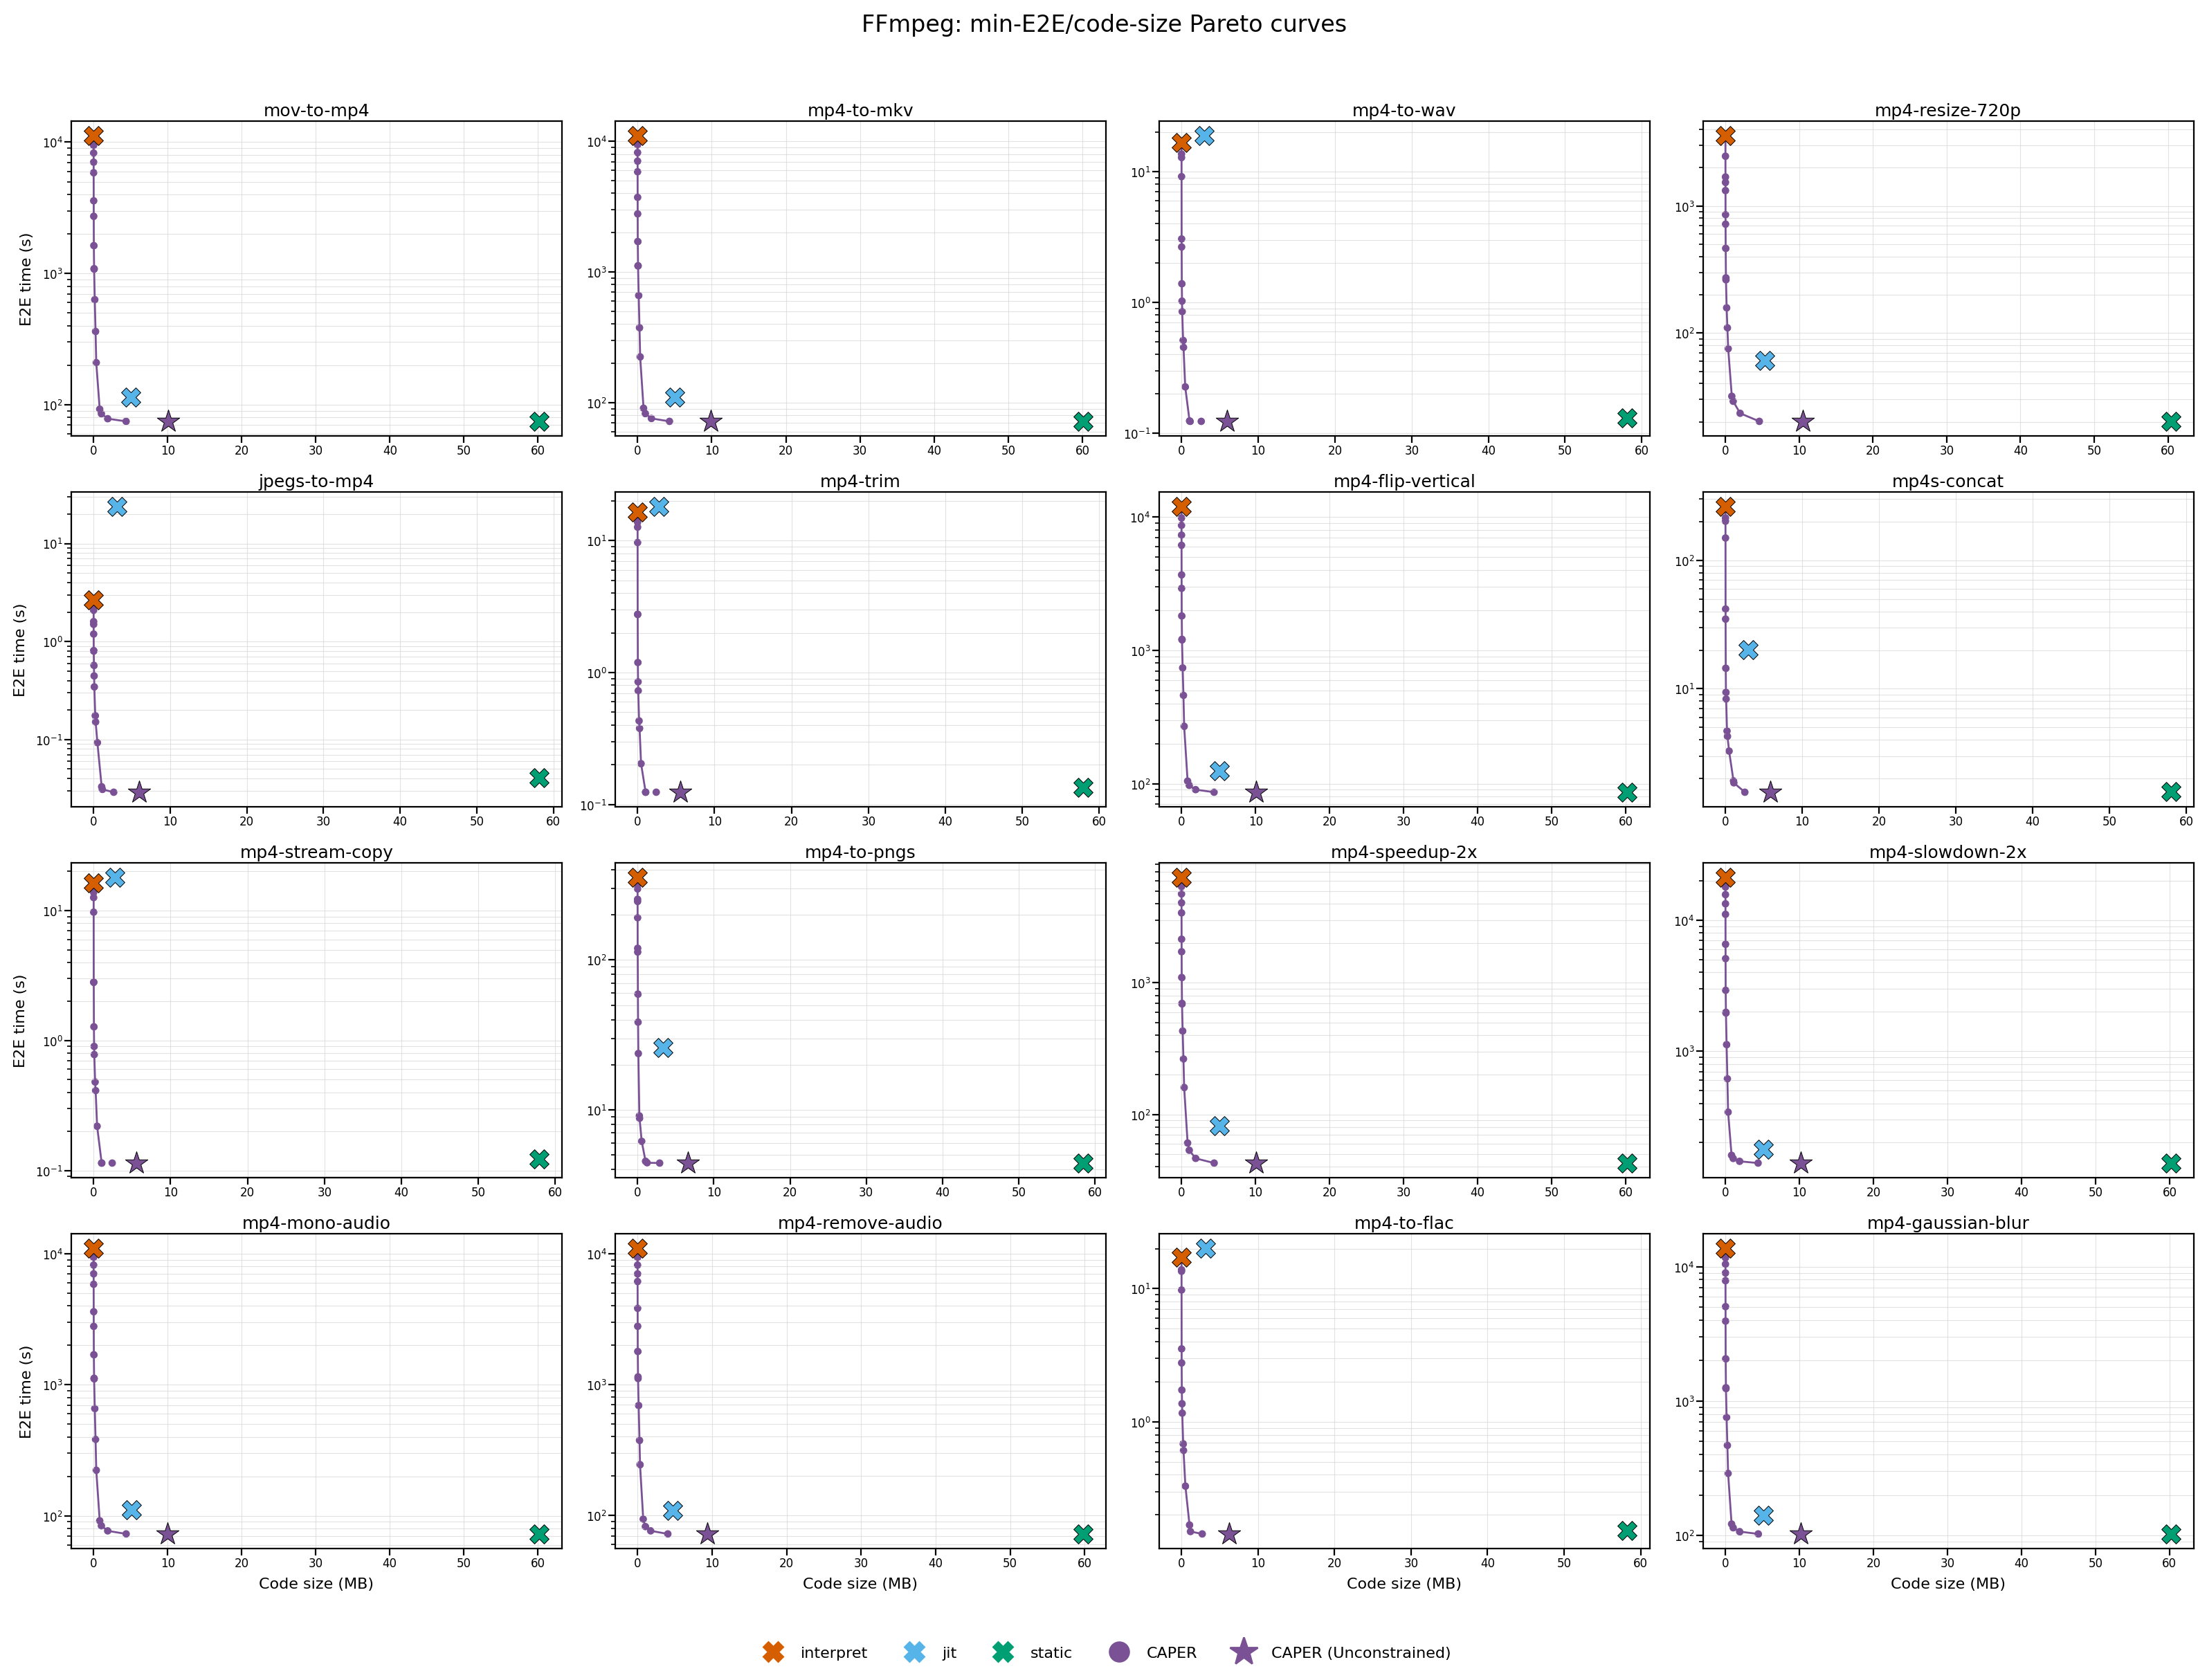

saved: evaluation/compilation-plan/out/pareto-curve.sqlite-all-workloads.pdf


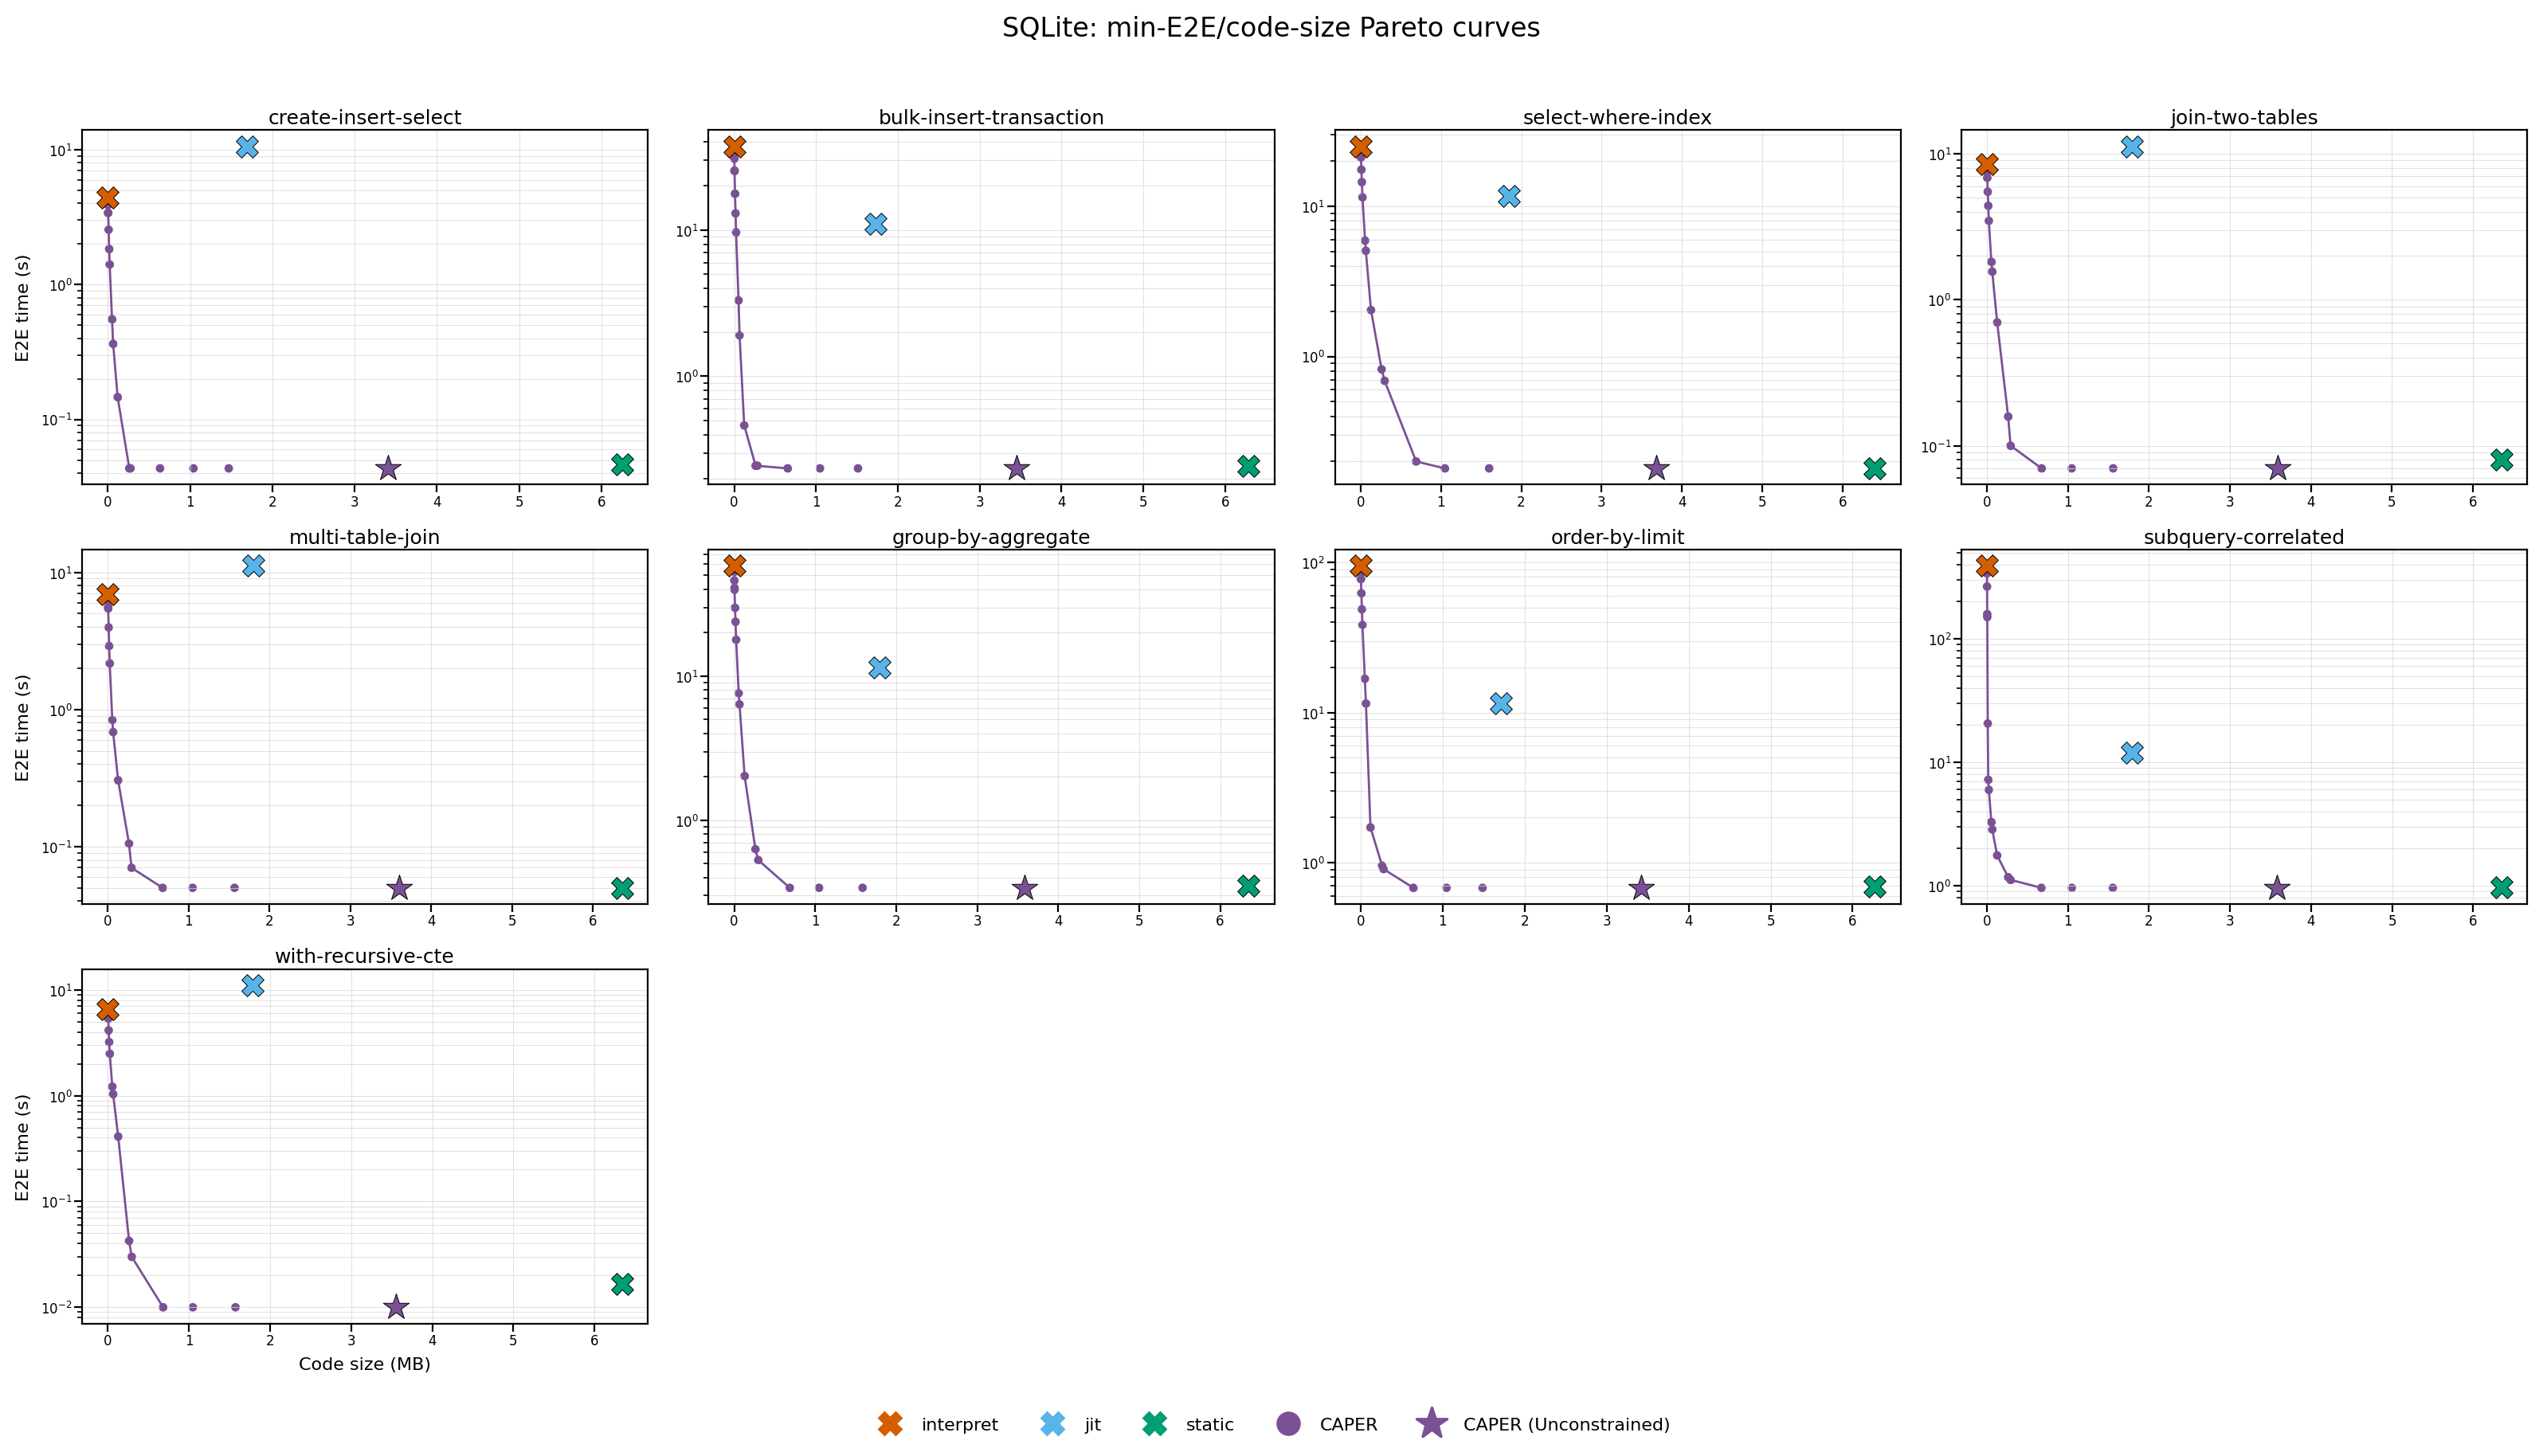

saved: evaluation/compilation-plan/out/pareto-curve.coremark-all-workloads.pdf


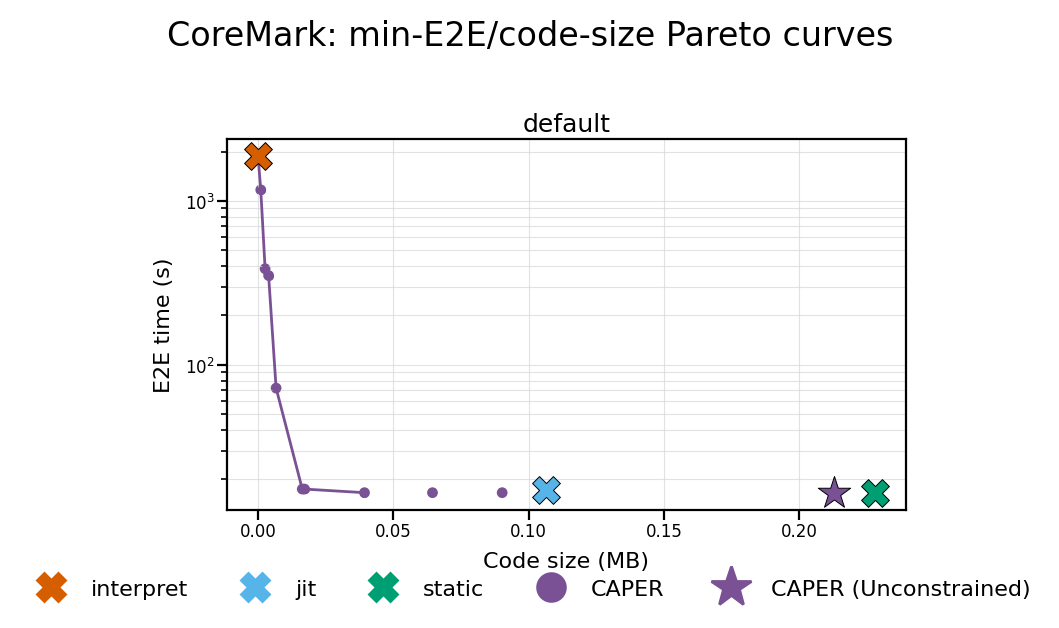

saved: evaluation/compilation-plan/out/pareto-curve.float-mm-all-workloads.pdf


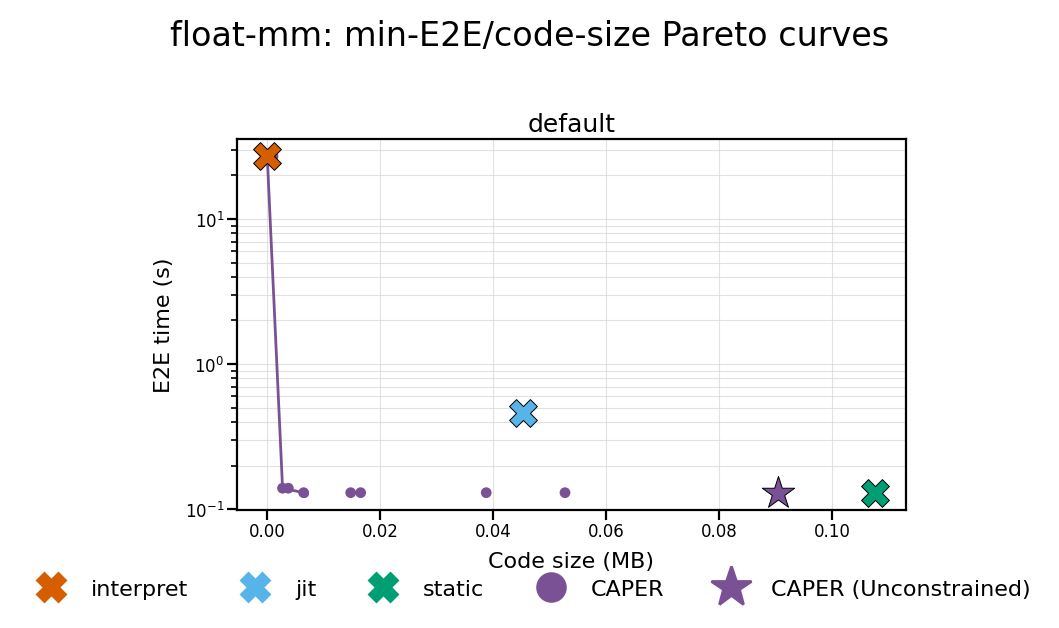

saved: evaluation/compilation-plan/out/pareto-curve.gcc-loops-all-workloads.pdf


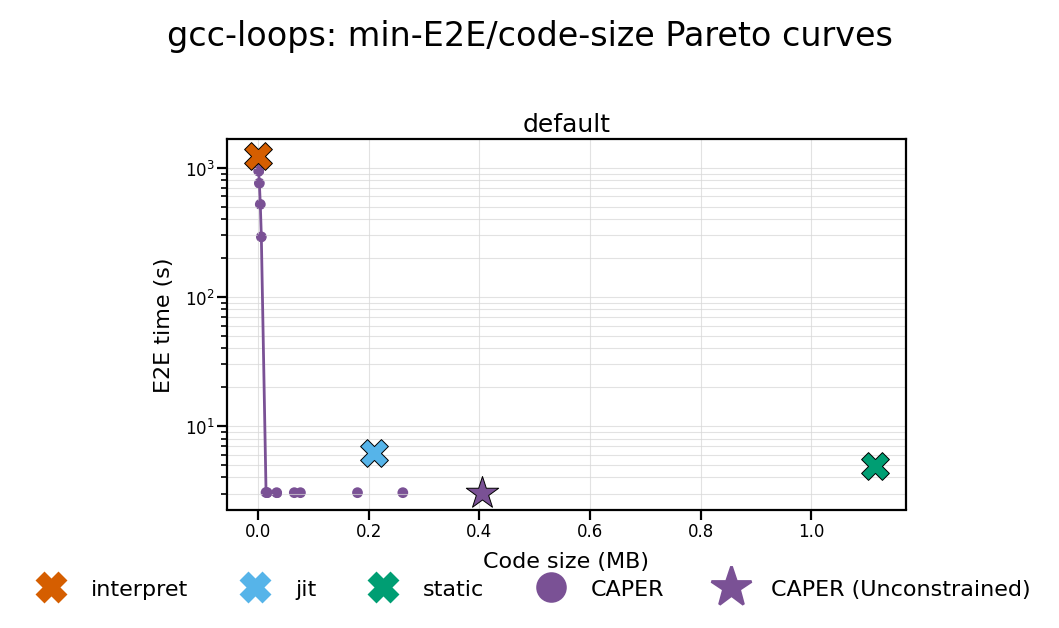

saved: evaluation/compilation-plan/out/pareto-curve.hashset-all-workloads.pdf


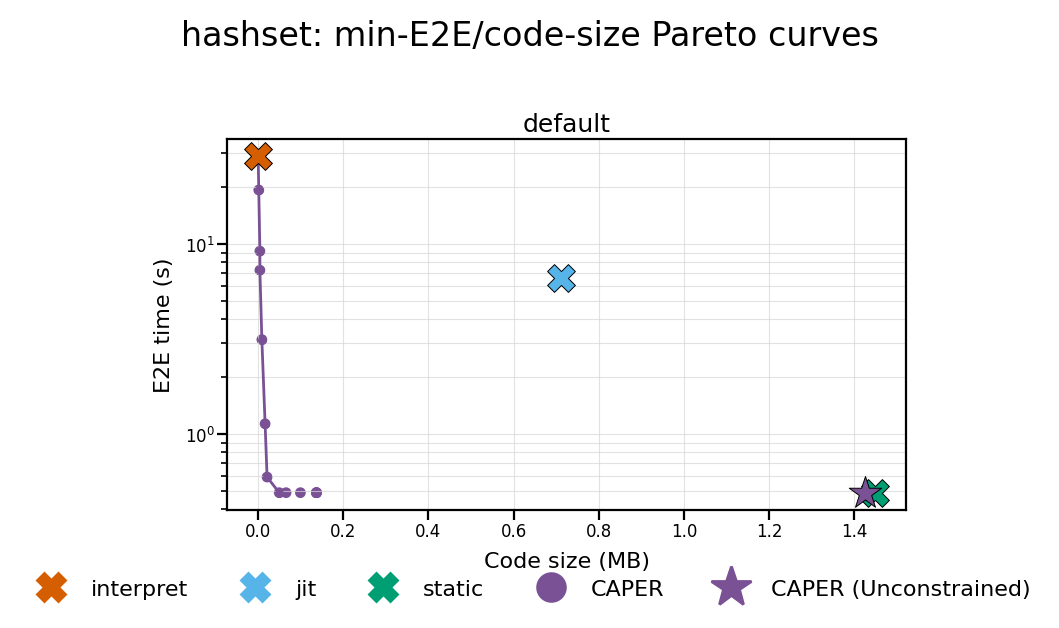

saved: evaluation/compilation-plan/out/pareto-curve.quicksort-all-workloads.pdf


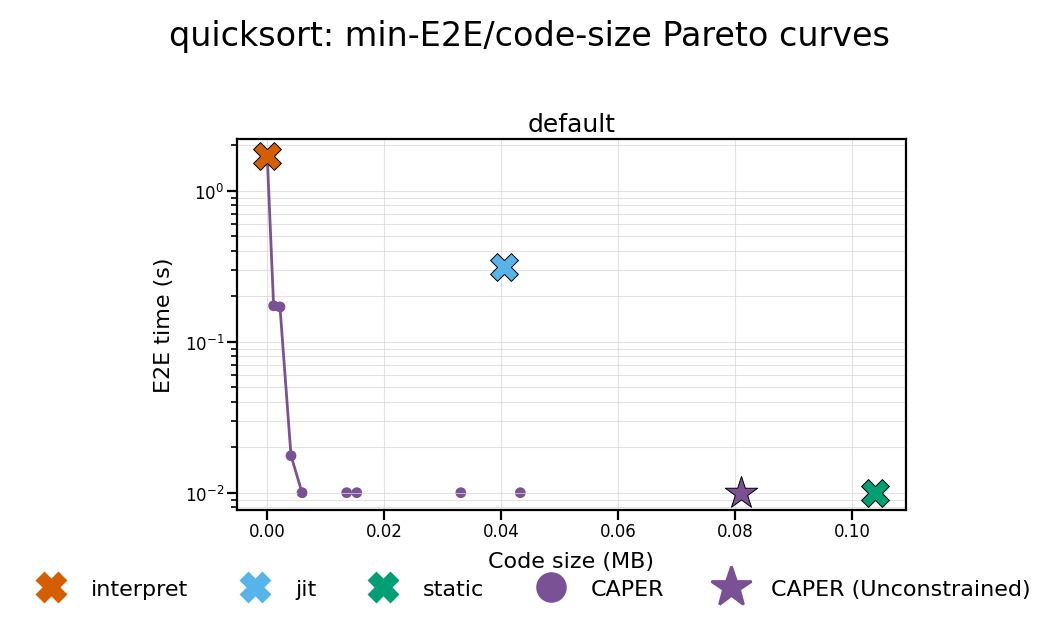

saved: evaluation/compilation-plan/out/pareto-curve.tsf-all-workloads.pdf


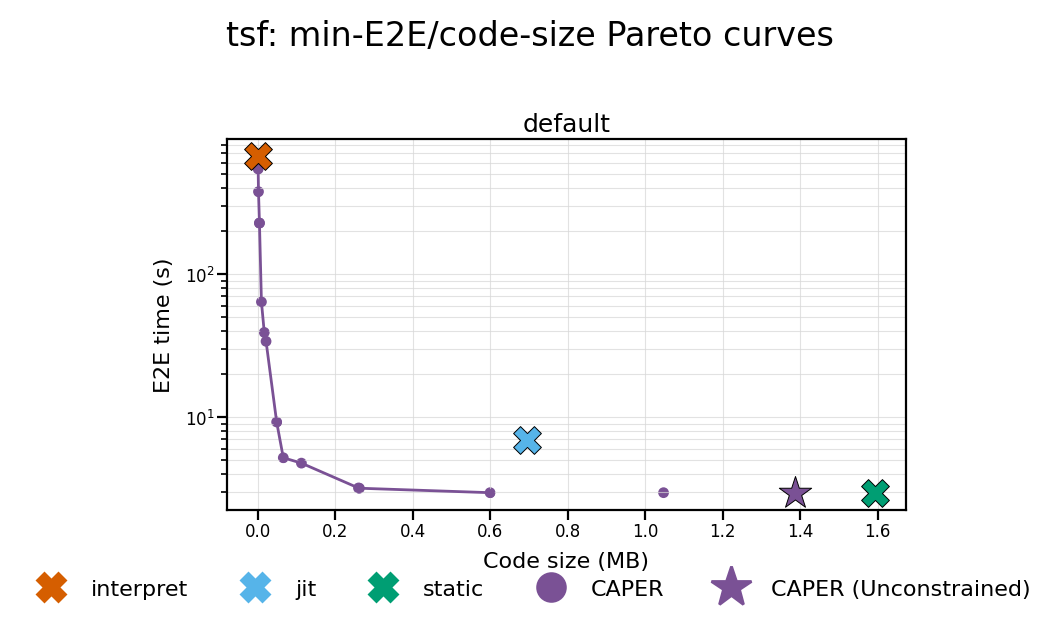

saved: evaluation/compilation-plan/out/pareto-curve.basicmath-all-workloads.pdf


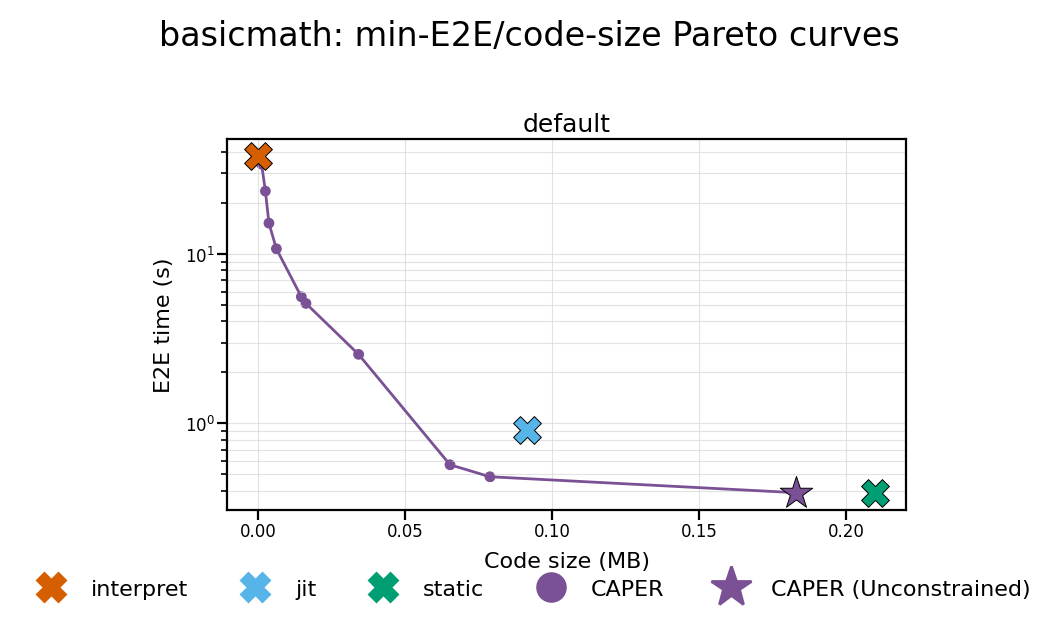

saved: evaluation/compilation-plan/out/pareto-curve.bitcount-all-workloads.pdf


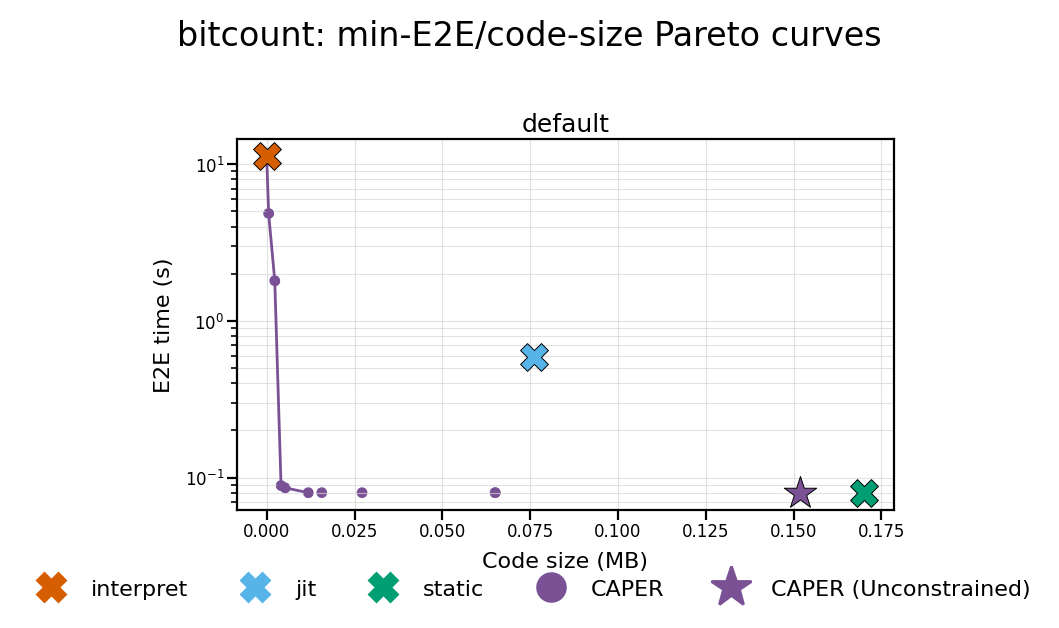

saved: evaluation/compilation-plan/out/pareto-curve.stringsearch-all-workloads.pdf


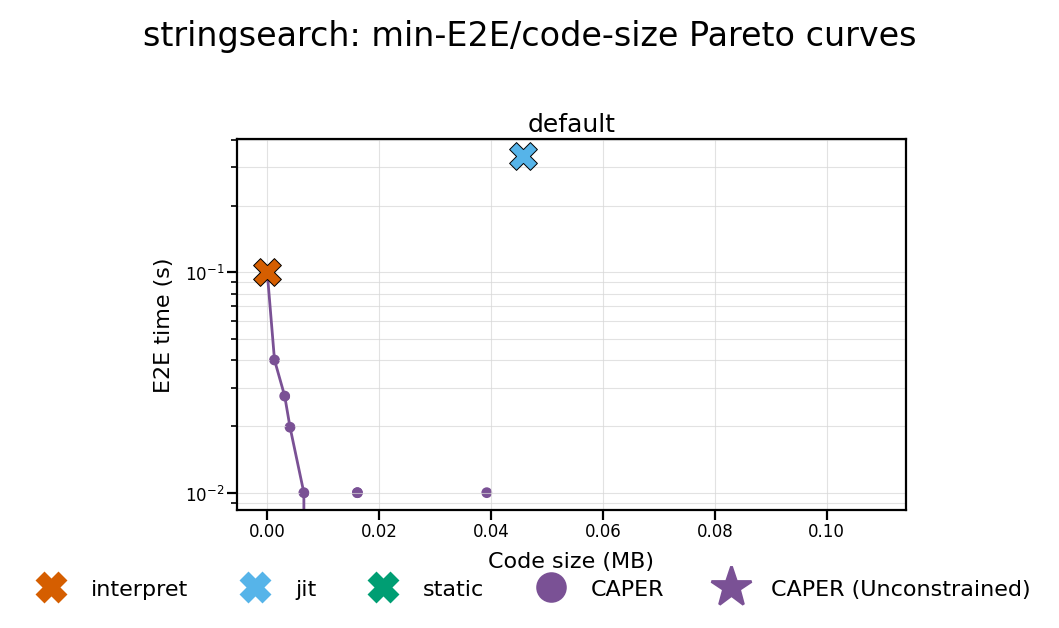

saved: evaluation/compilation-plan/out/pareto-curve.cjpeg-all-workloads.pdf


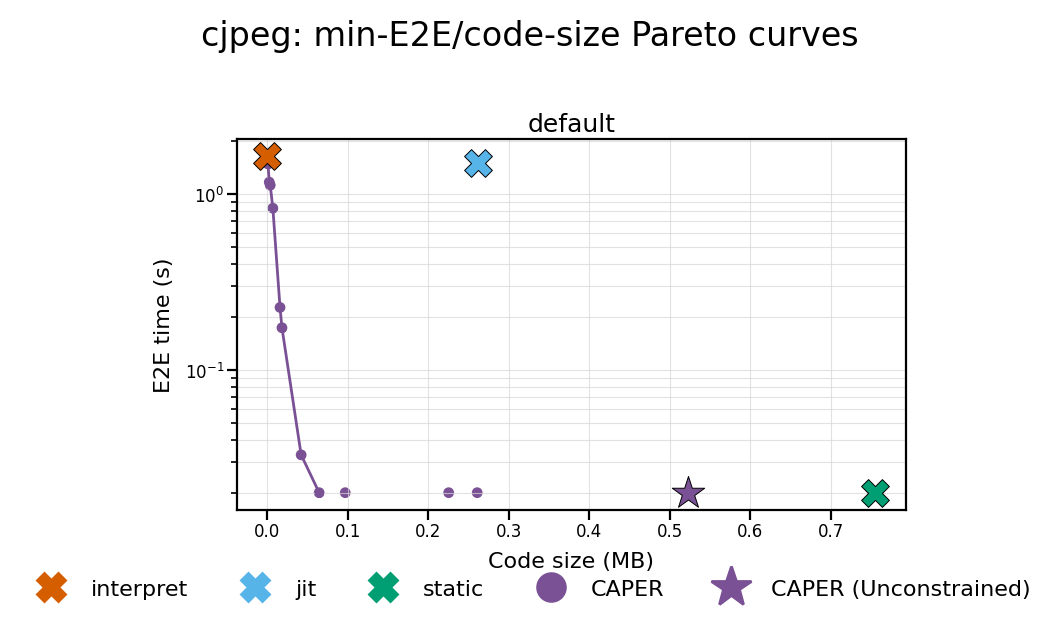

saved: evaluation/compilation-plan/out/pareto-curve.djpeg-all-workloads.pdf


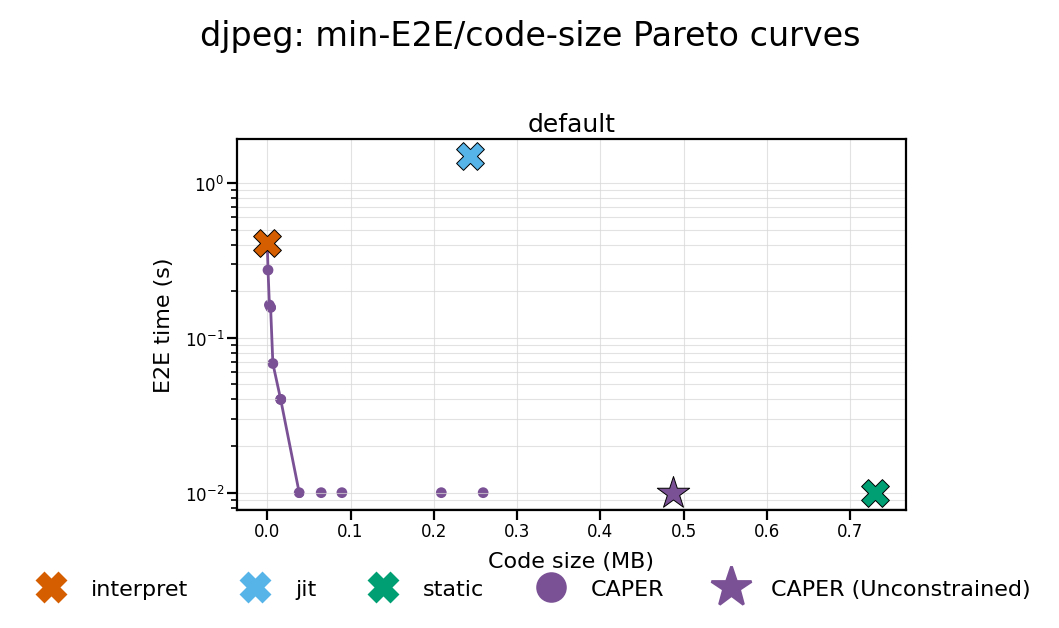

saved: evaluation/compilation-plan/out/pareto-curve.rawcaudio-all-workloads.pdf


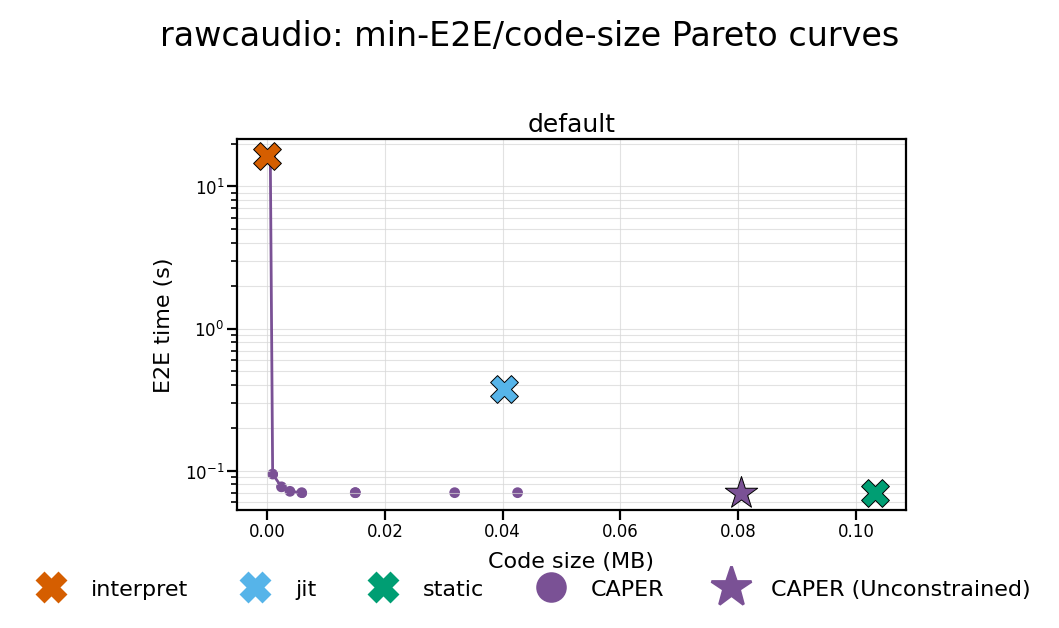

saved: evaluation/compilation-plan/out/pareto-curve.rawdaudio-all-workloads.pdf


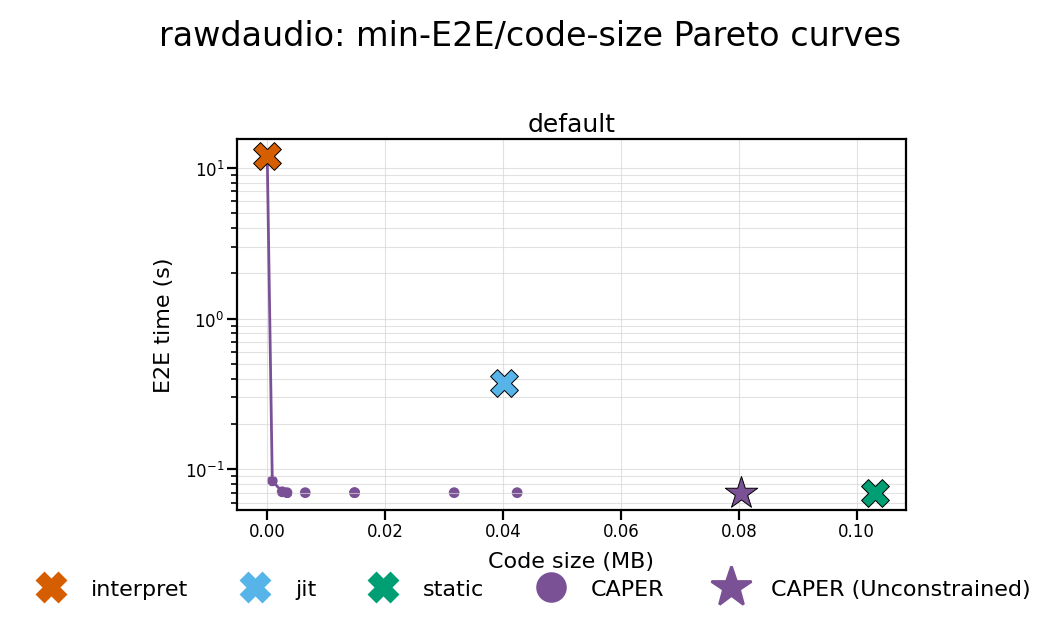

saved: evaluation/compilation-plan/out/pareto-curve.blowfish-encode-all-workloads.pdf


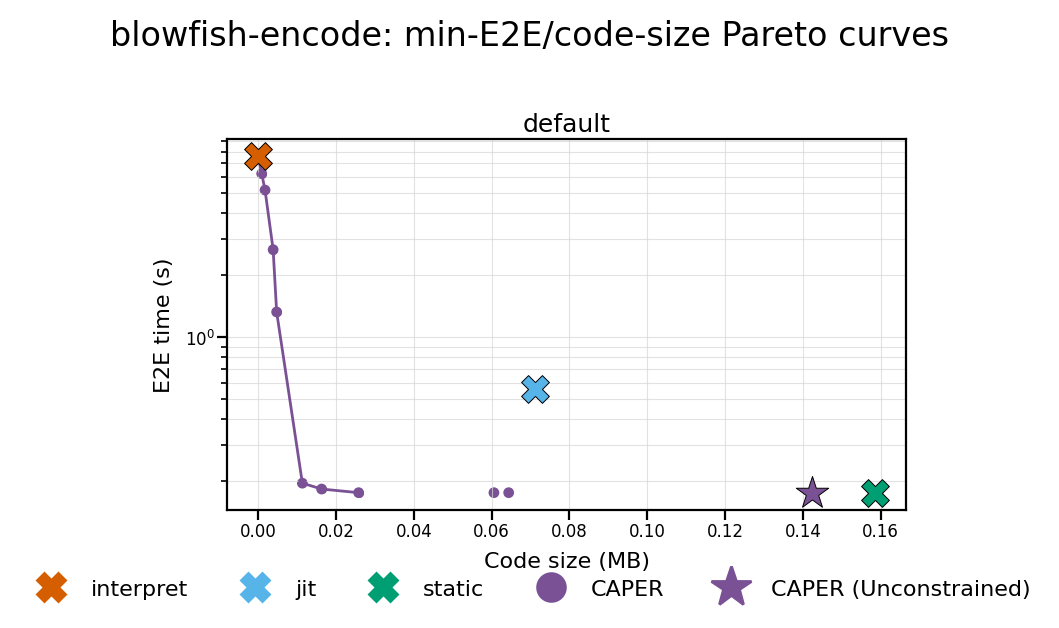

saved: evaluation/compilation-plan/out/pareto-curve.rijndael-encode-all-workloads.pdf


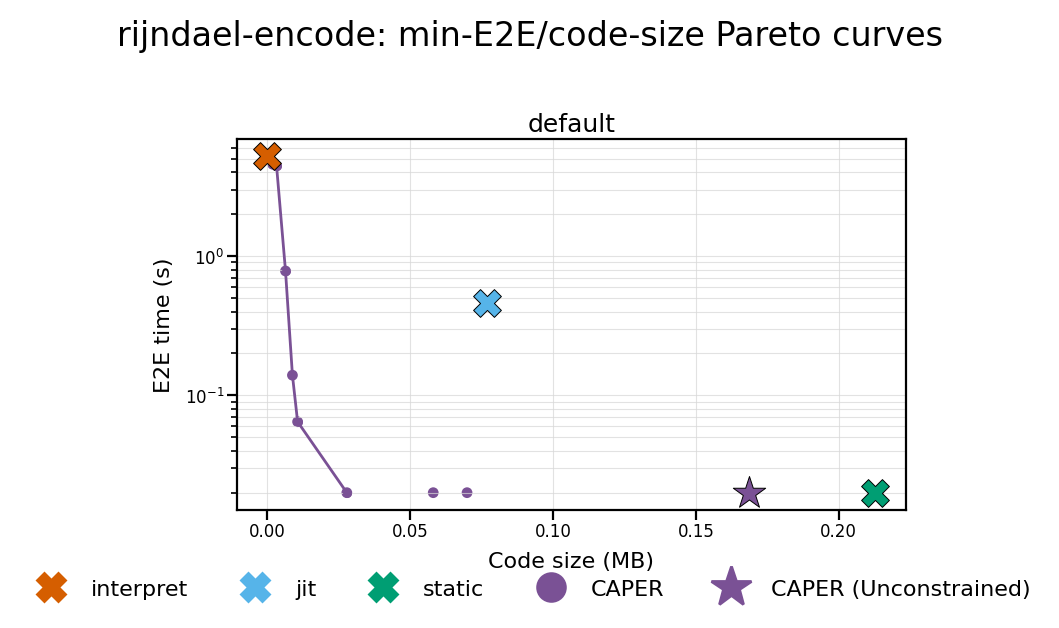

saved: evaluation/compilation-plan/out/pareto-curve.crc32-all-workloads.pdf


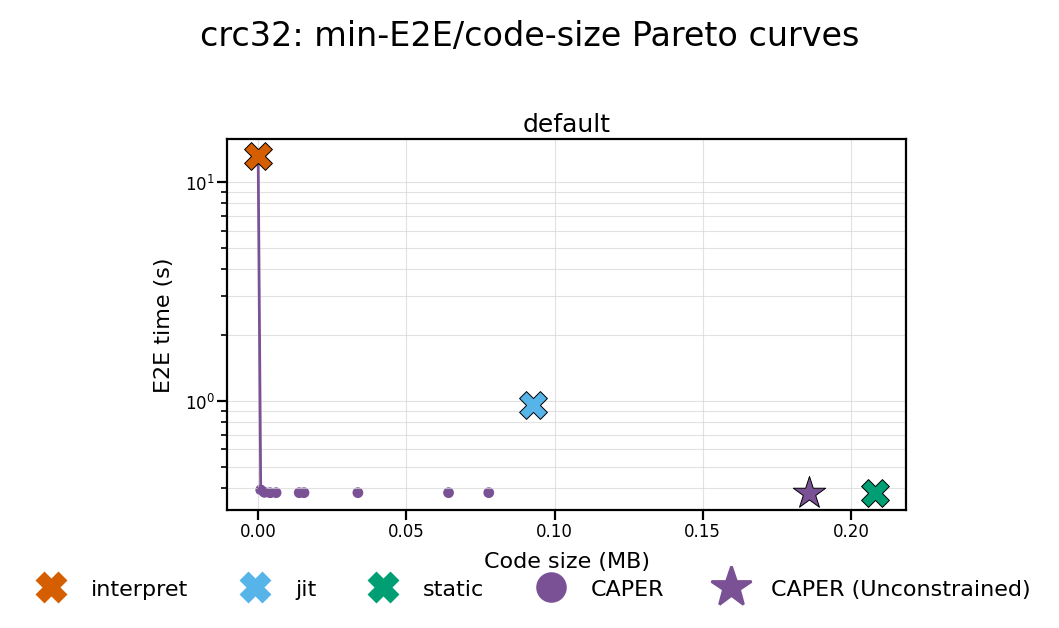

saved: evaluation/compilation-plan/out/pareto-curve.sha-all-workloads.pdf


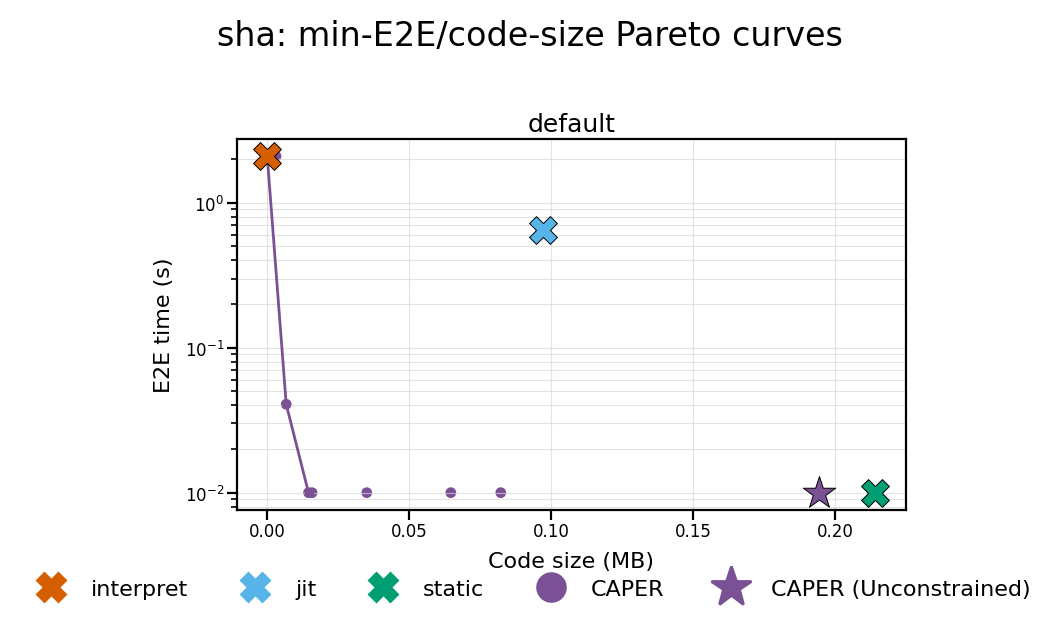

saved: evaluation/compilation-plan/out/pareto-curve.bt-all-workloads.pdf


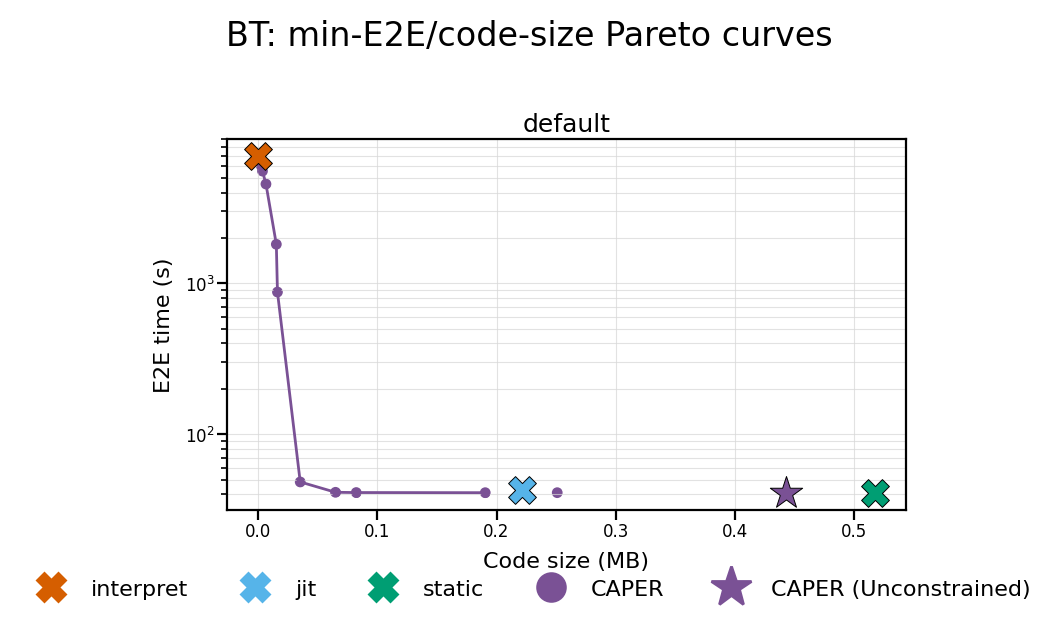

saved: evaluation/compilation-plan/out/pareto-curve.cg-all-workloads.pdf


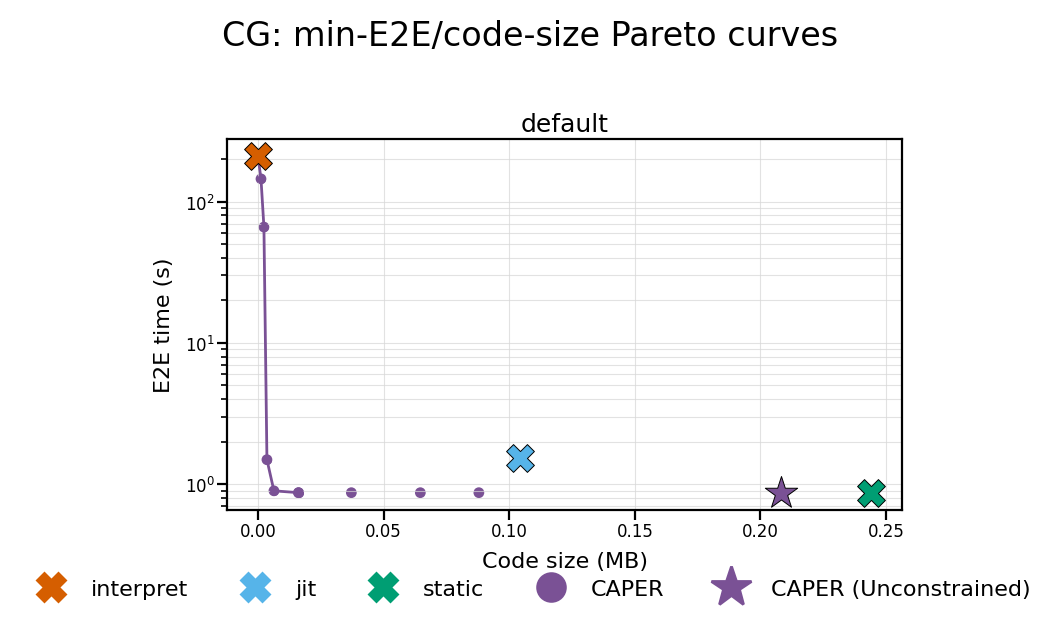

saved: evaluation/compilation-plan/out/pareto-curve.ep-all-workloads.pdf


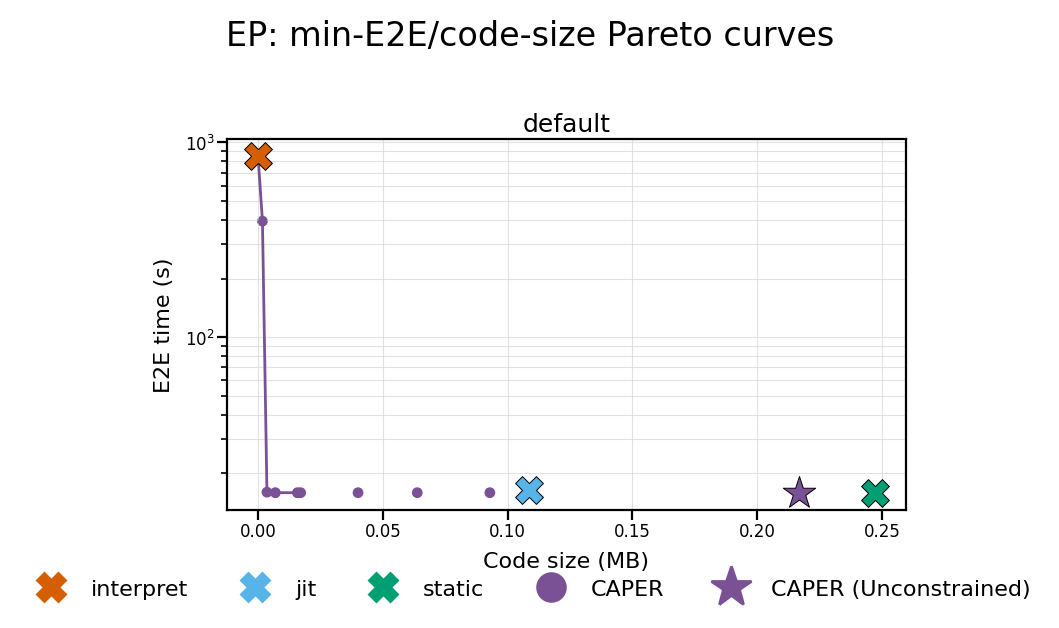

saved: evaluation/compilation-plan/out/pareto-curve.ft-all-workloads.pdf


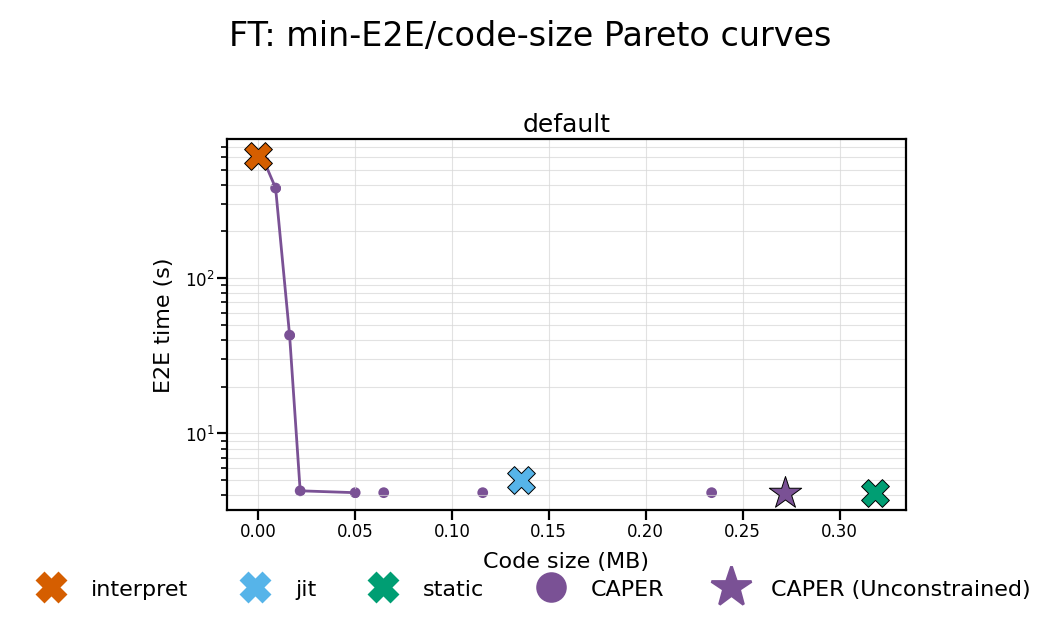

saved: evaluation/compilation-plan/out/pareto-curve.is-all-workloads.pdf


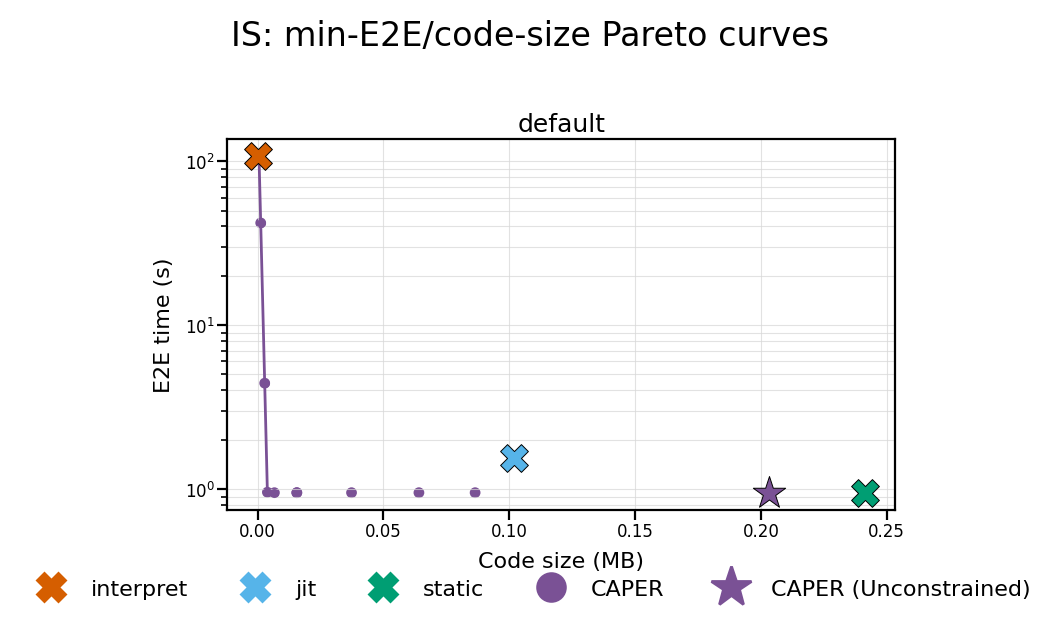

saved: evaluation/compilation-plan/out/pareto-curve.lu-all-workloads.pdf


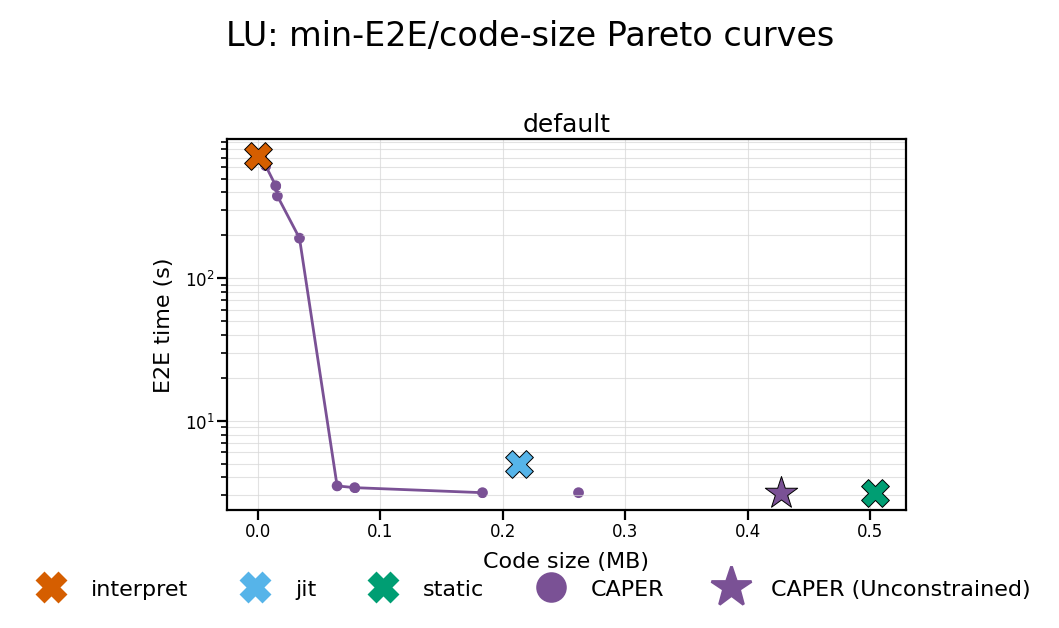

saved: evaluation/compilation-plan/out/pareto-curve.mg-all-workloads.pdf


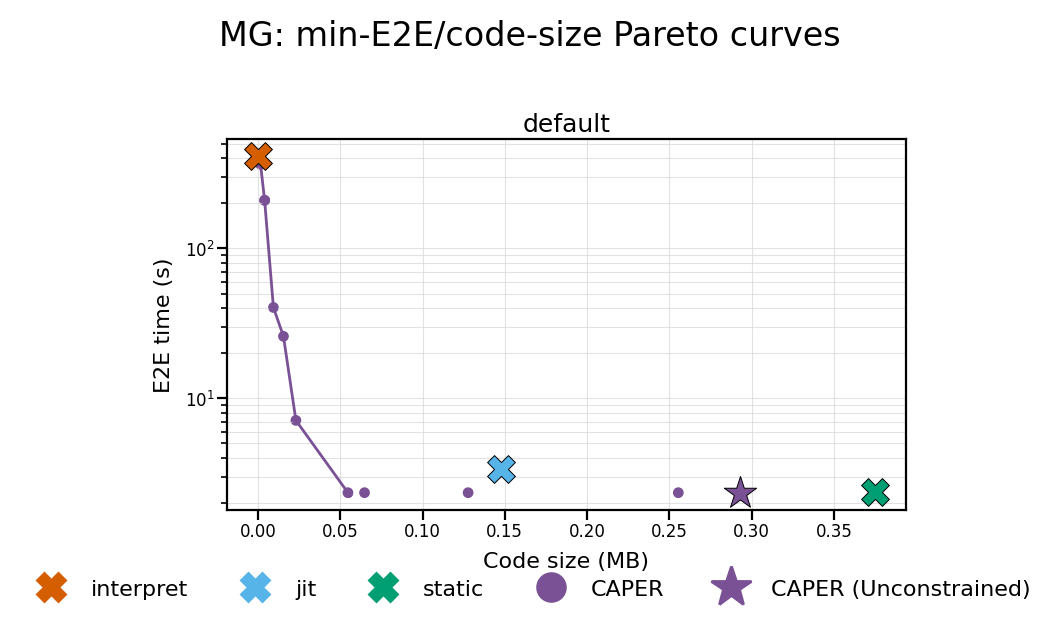

saved: evaluation/compilation-plan/out/pareto-curve.sp-all-workloads.pdf


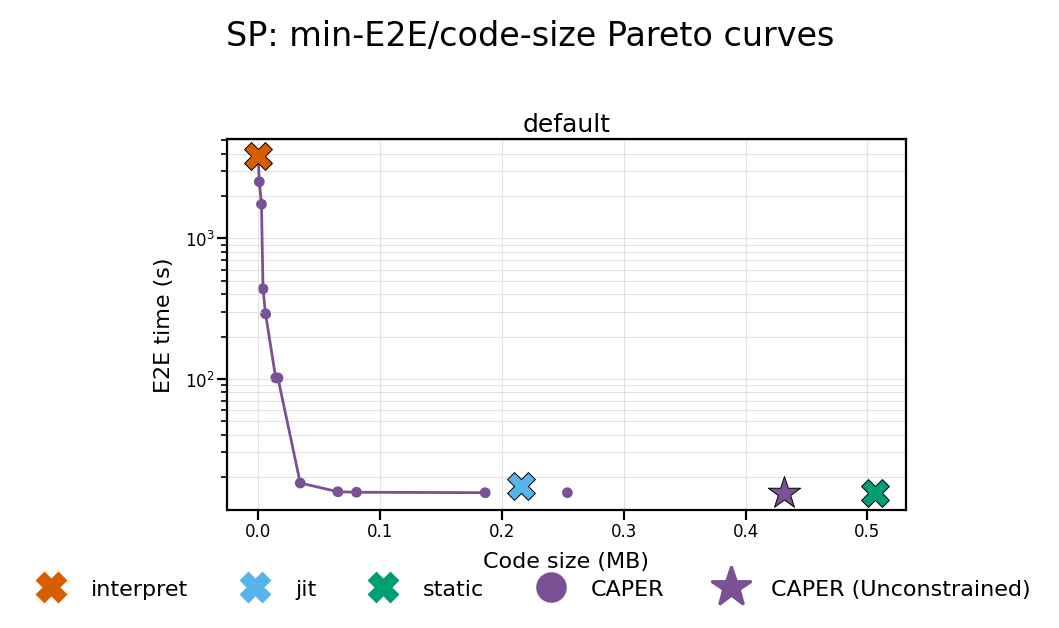

saved: evaluation/compilation-plan/out/pareto-curve.correlation-all-workloads.pdf


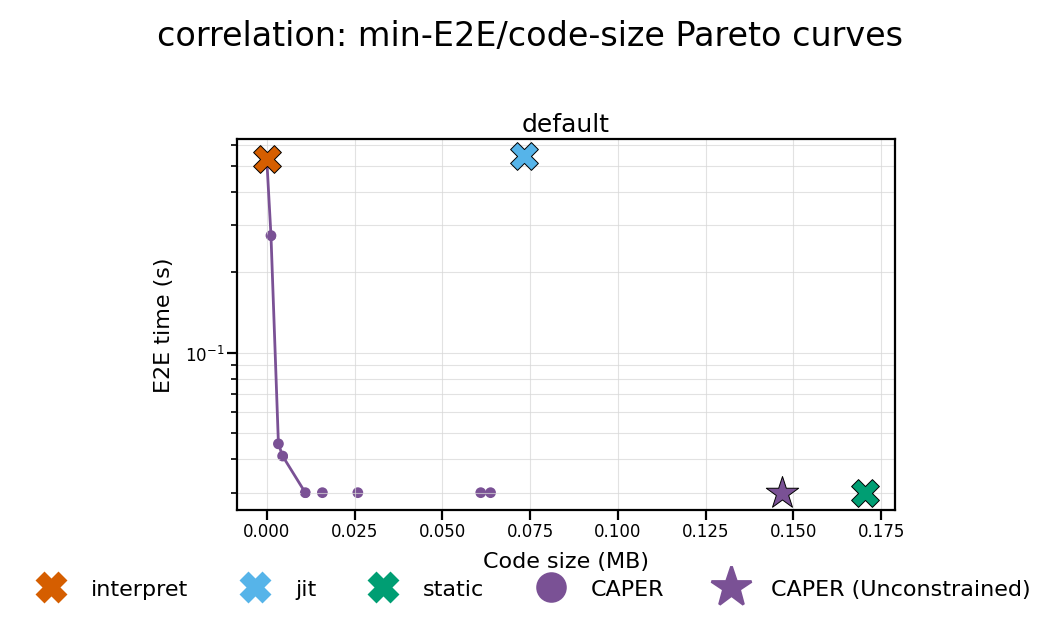

saved: evaluation/compilation-plan/out/pareto-curve.covariance-all-workloads.pdf


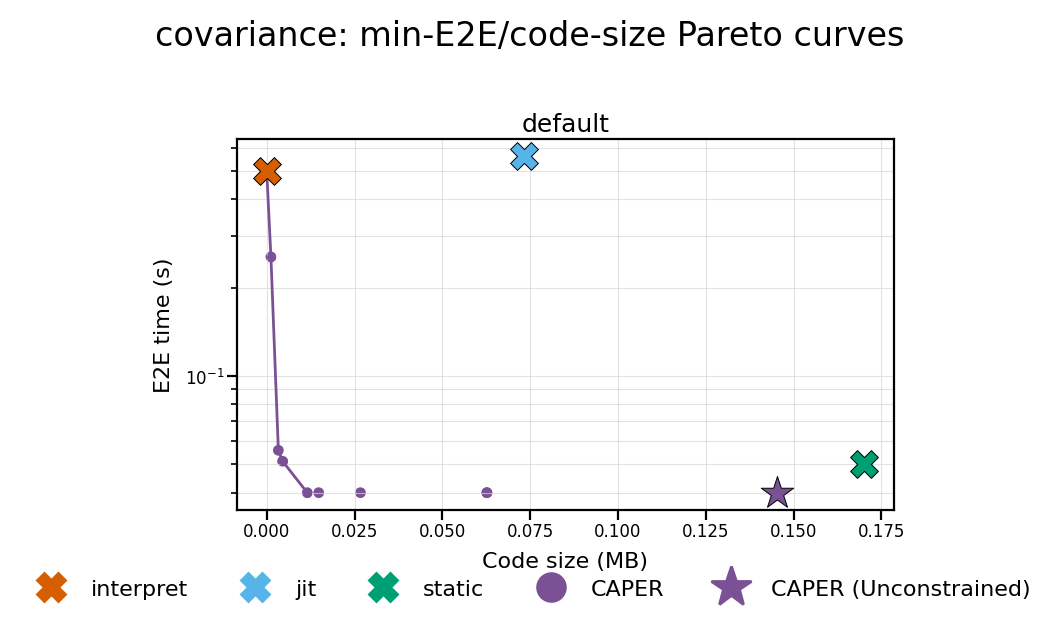

saved: evaluation/compilation-plan/out/pareto-curve.2mm-all-workloads.pdf


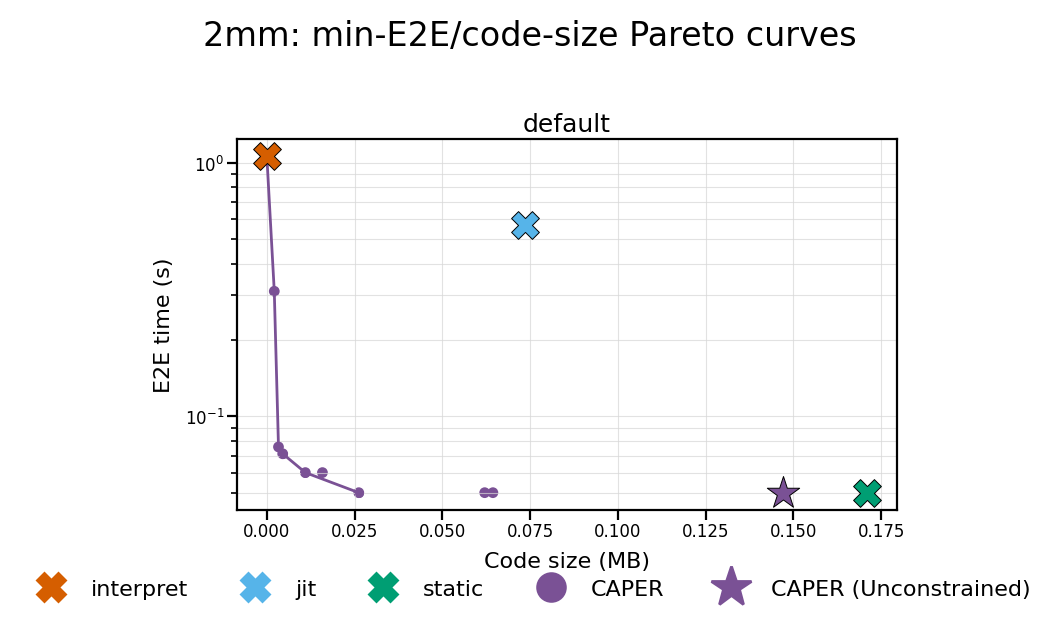

saved: evaluation/compilation-plan/out/pareto-curve.3mm-all-workloads.pdf


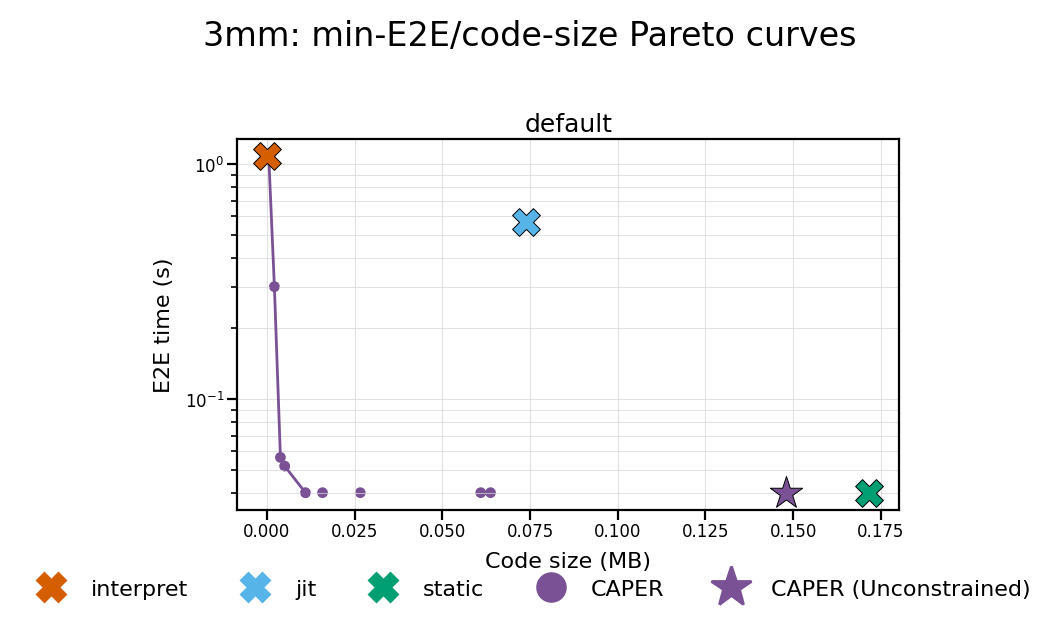

saved: evaluation/compilation-plan/out/pareto-curve.atax-all-workloads.pdf


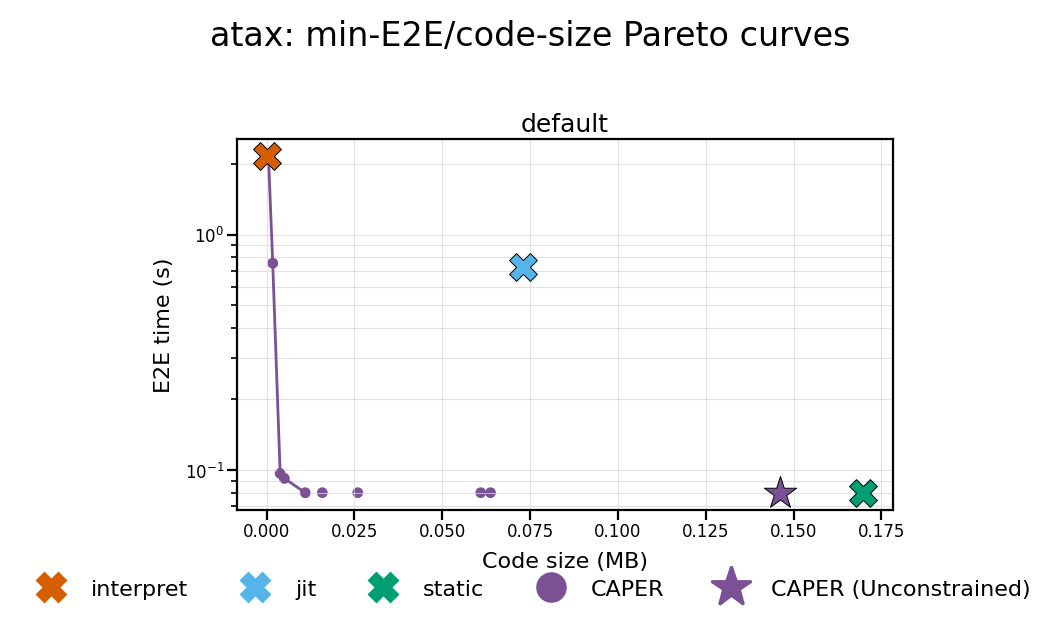

saved: evaluation/compilation-plan/out/pareto-curve.bicg-all-workloads.pdf


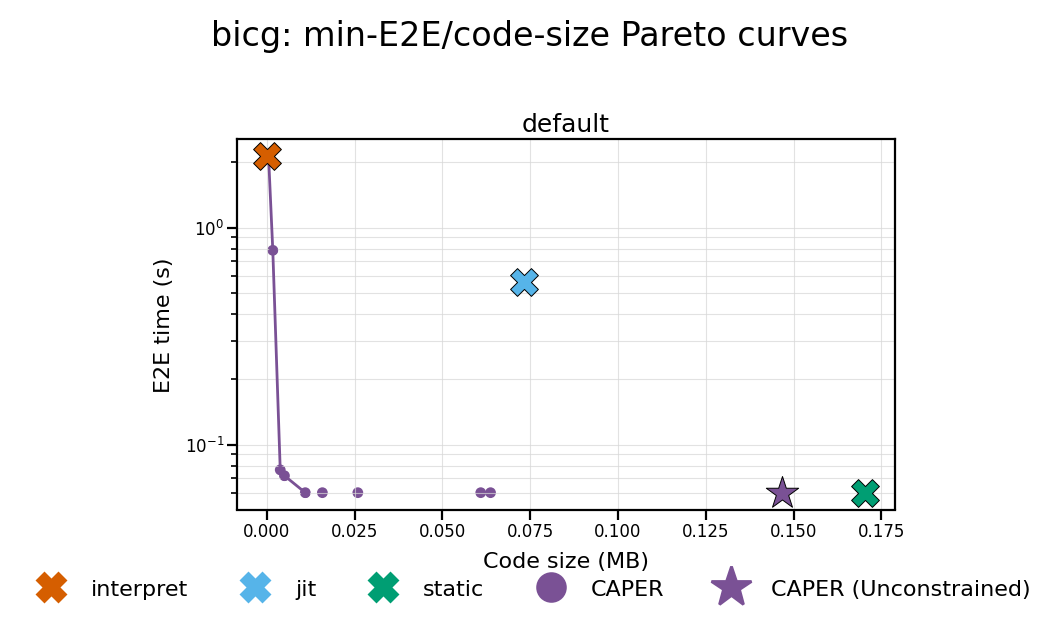

saved: evaluation/compilation-plan/out/pareto-curve.doitgen-all-workloads.pdf


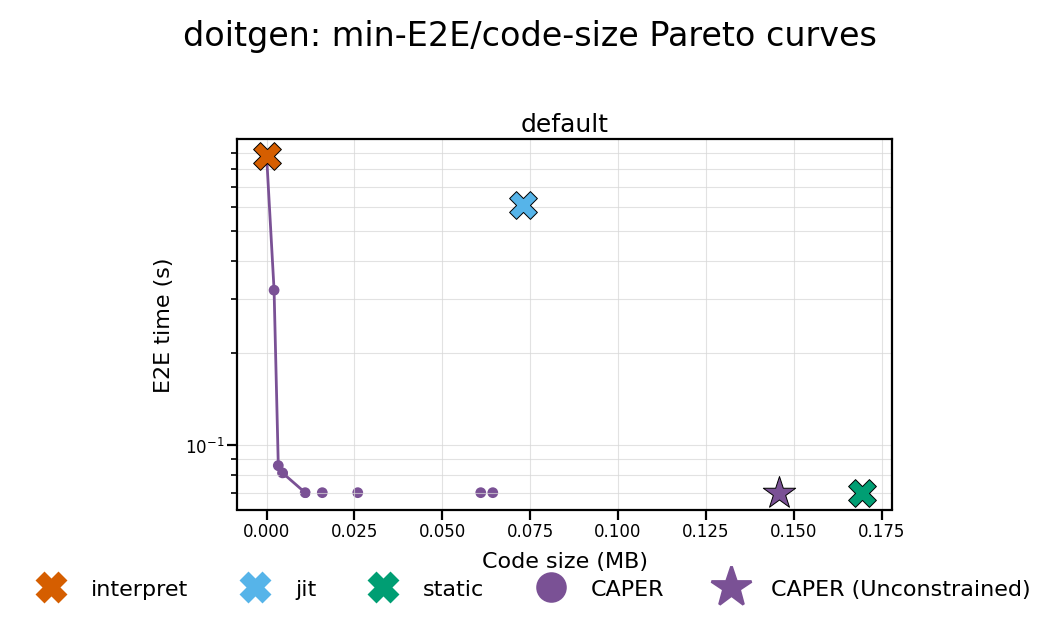

saved: evaluation/compilation-plan/out/pareto-curve.mvt-all-workloads.pdf


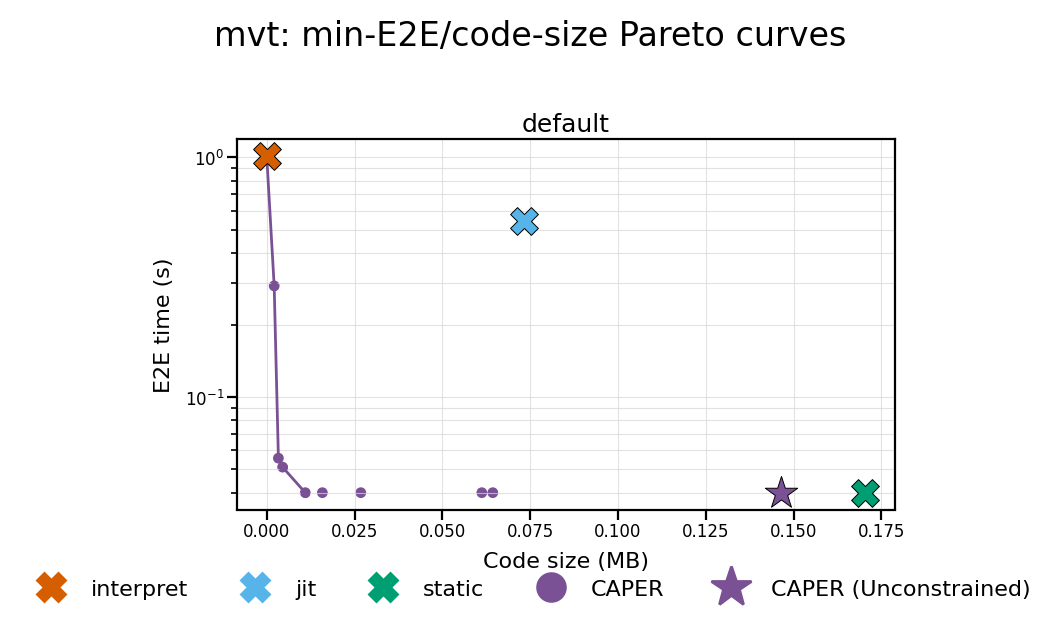

saved: evaluation/compilation-plan/out/pareto-curve.gemm-all-workloads.pdf


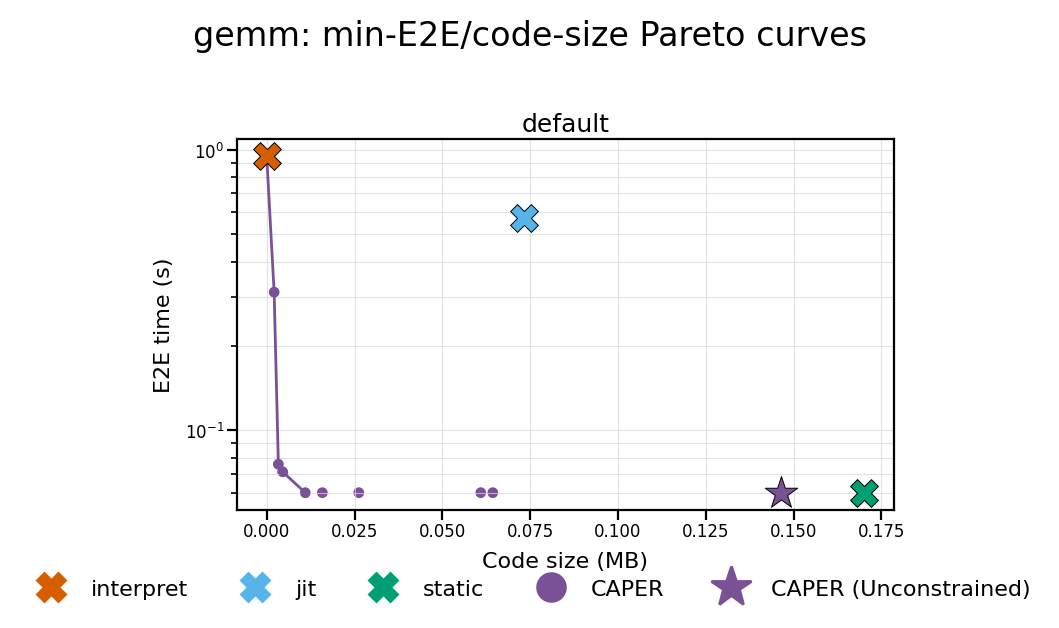

saved: evaluation/compilation-plan/out/pareto-curve.gemver-all-workloads.pdf


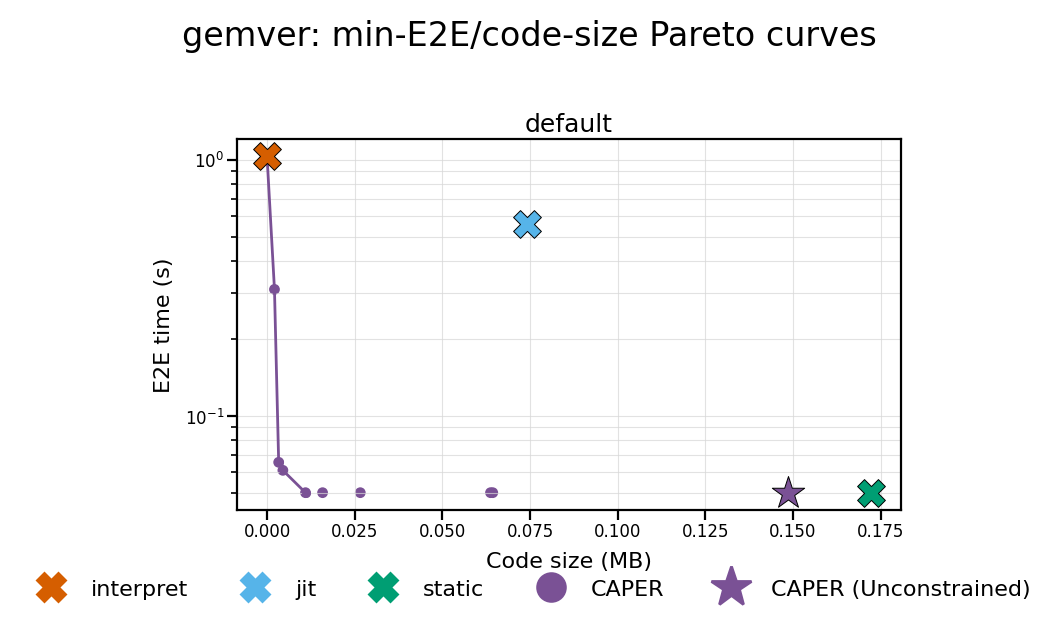

saved: evaluation/compilation-plan/out/pareto-curve.gesummv-all-workloads.pdf


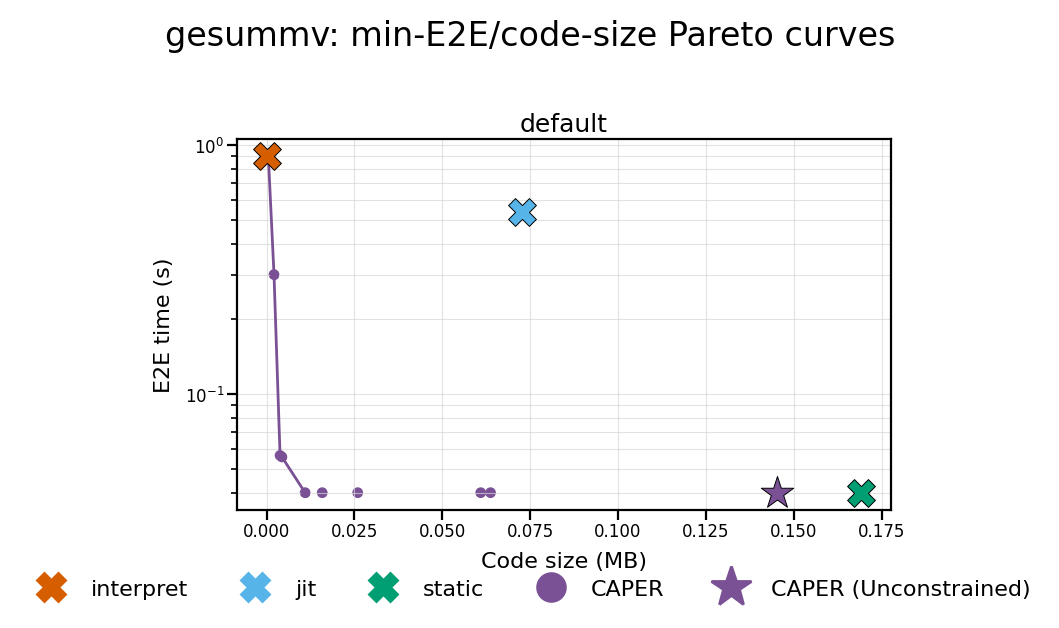

saved: evaluation/compilation-plan/out/pareto-curve.symm-all-workloads.pdf


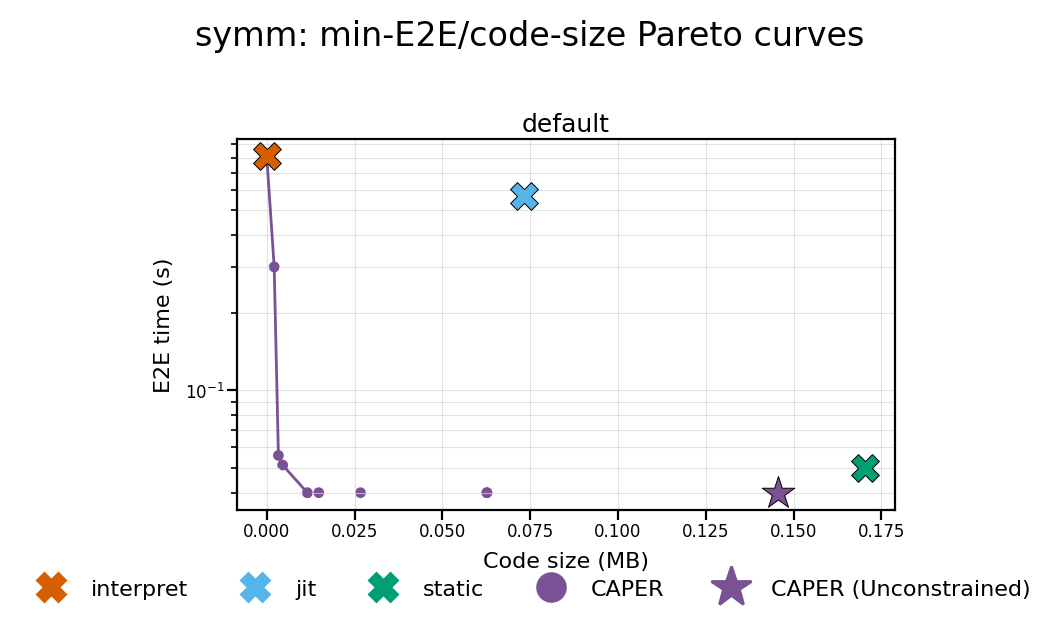

saved: evaluation/compilation-plan/out/pareto-curve.syr2k-all-workloads.pdf


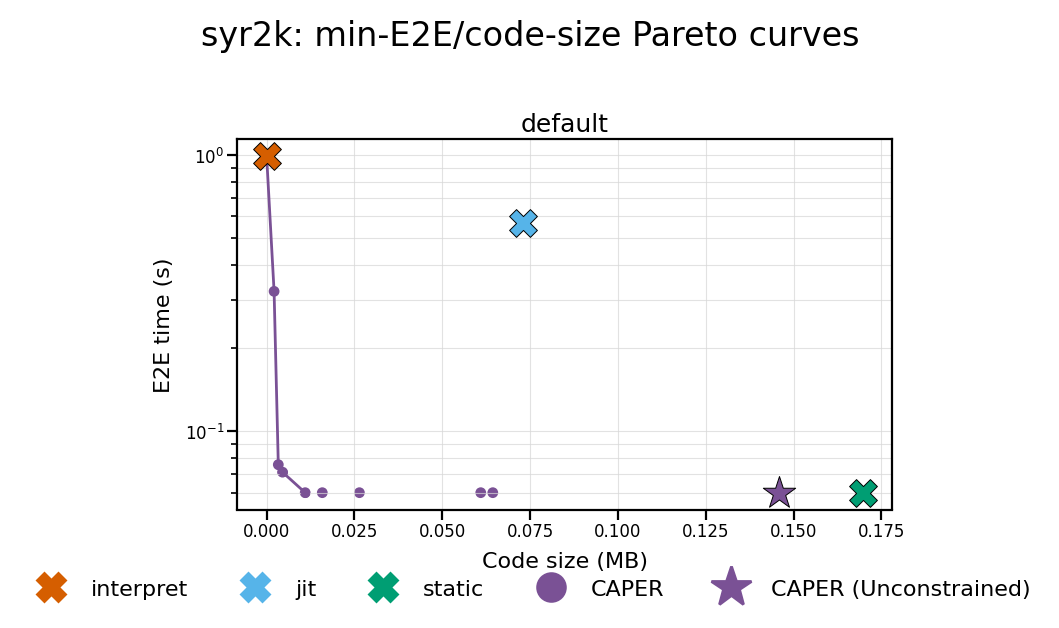

saved: evaluation/compilation-plan/out/pareto-curve.syrk-all-workloads.pdf


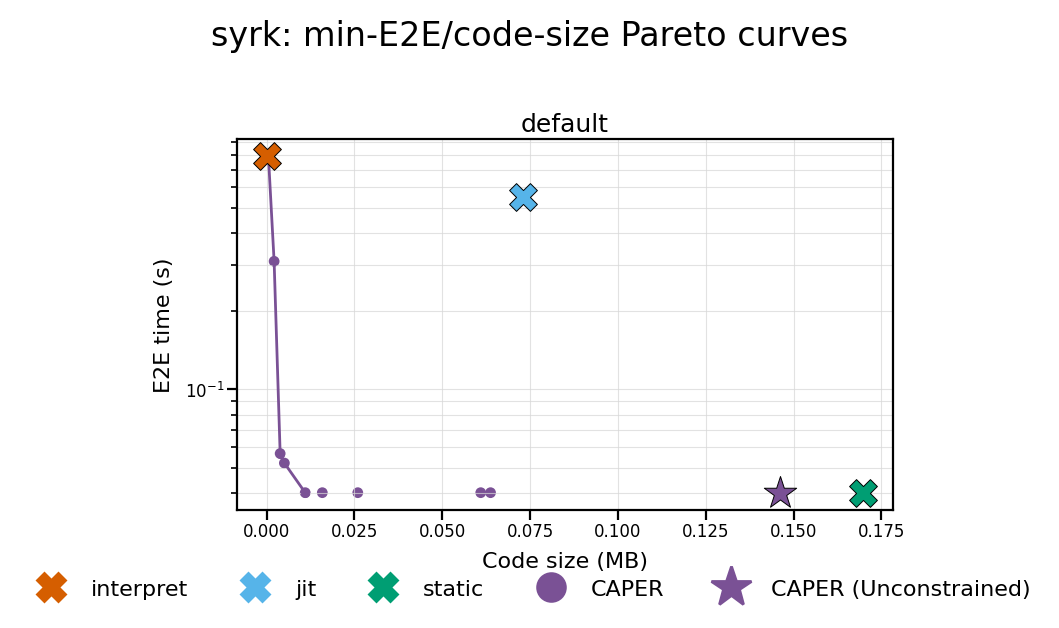

saved: evaluation/compilation-plan/out/pareto-curve.trmm-all-workloads.pdf


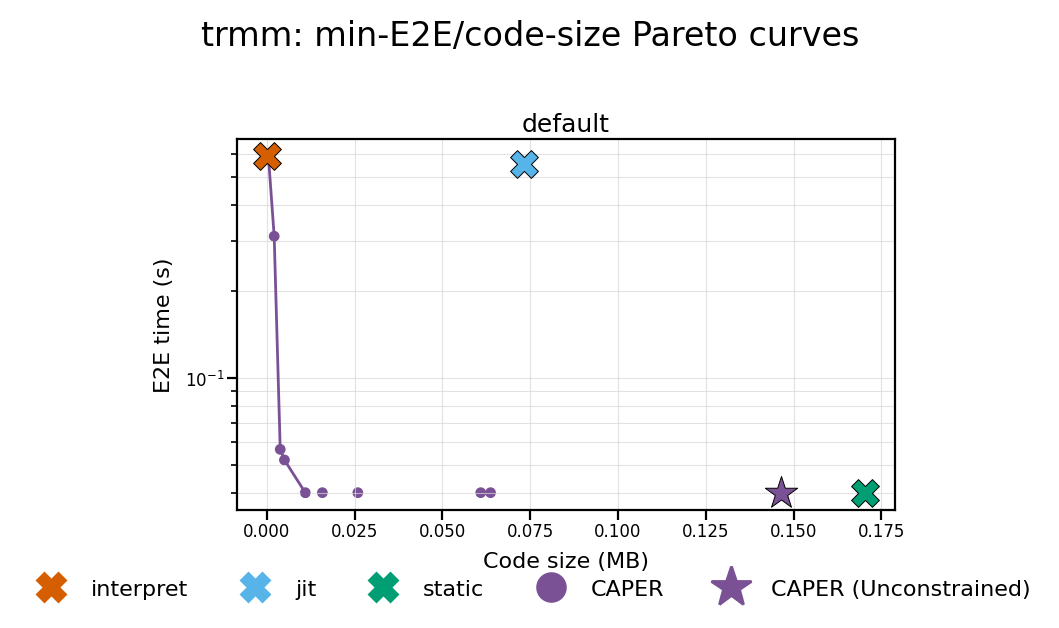

saved: evaluation/compilation-plan/out/pareto-curve.cholesky-all-workloads.pdf


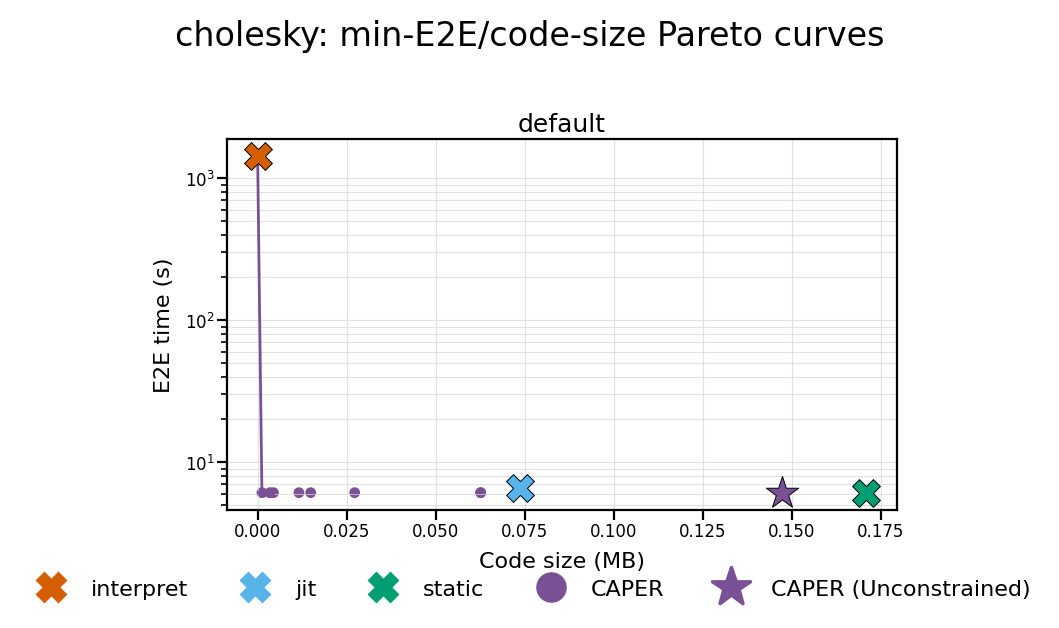

saved: evaluation/compilation-plan/out/pareto-curve.durbin-all-workloads.pdf


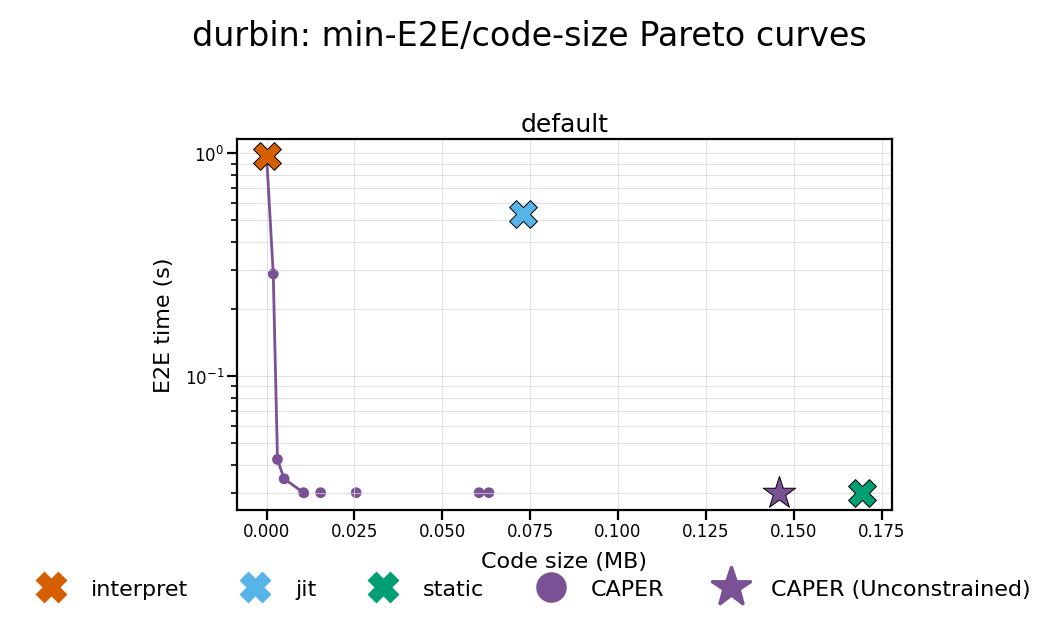

saved: evaluation/compilation-plan/out/pareto-curve.gramschmidt-all-workloads.pdf


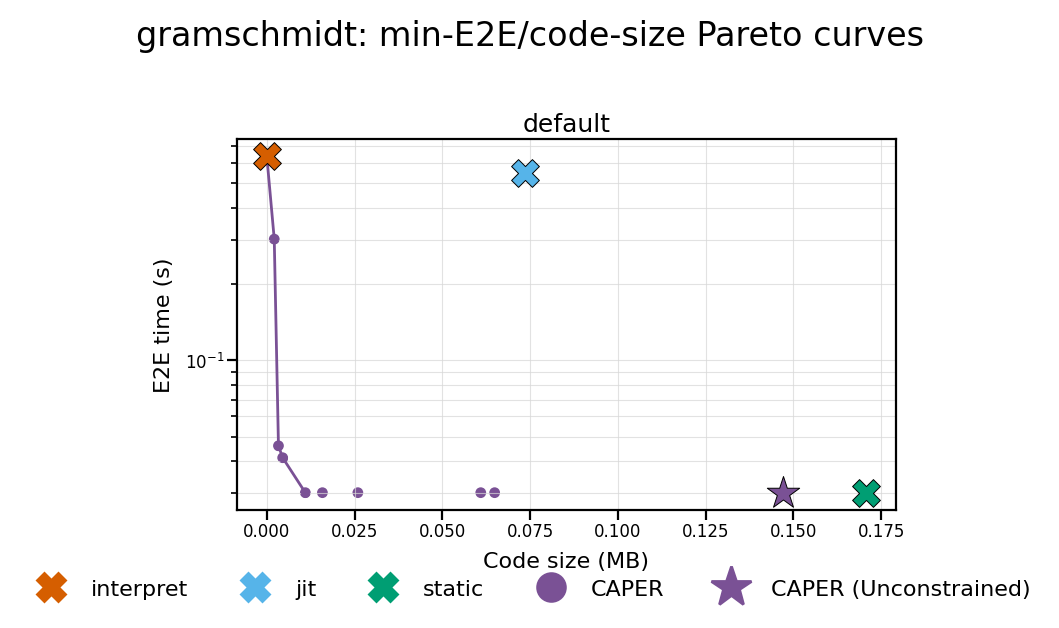

saved: evaluation/compilation-plan/out/pareto-curve.lu-all-workloads.pdf


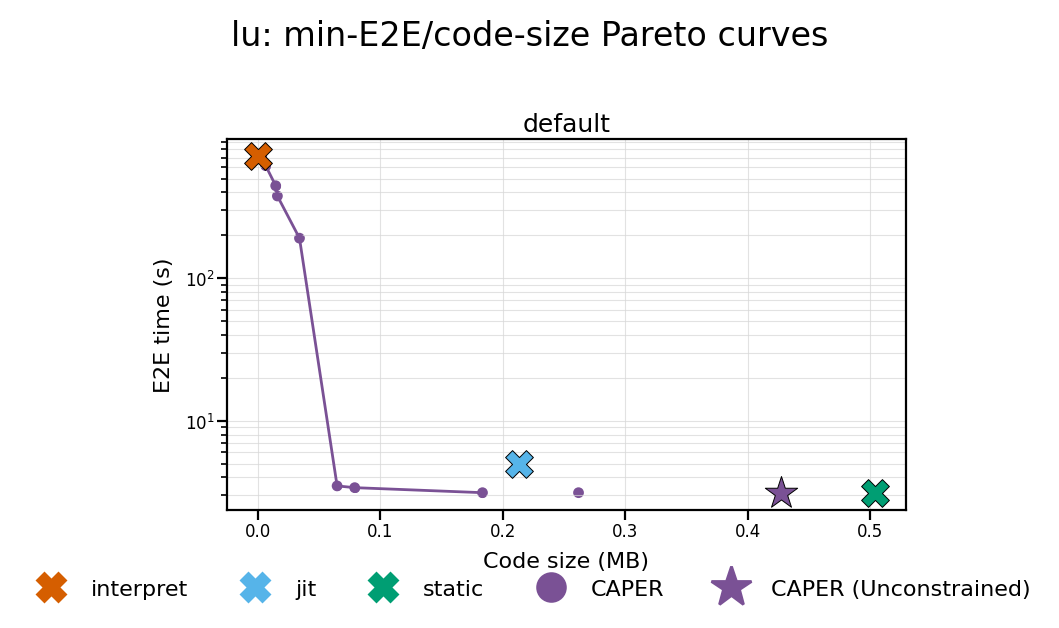

saved: evaluation/compilation-plan/out/pareto-curve.ludcmp-all-workloads.pdf


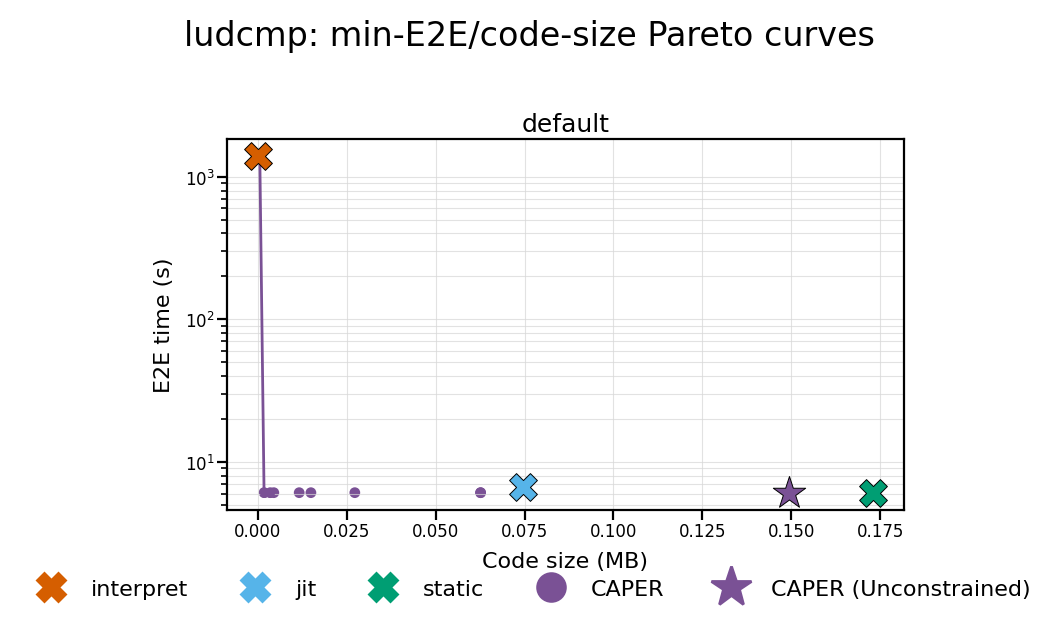

saved: evaluation/compilation-plan/out/pareto-curve.trisolv-all-workloads.pdf


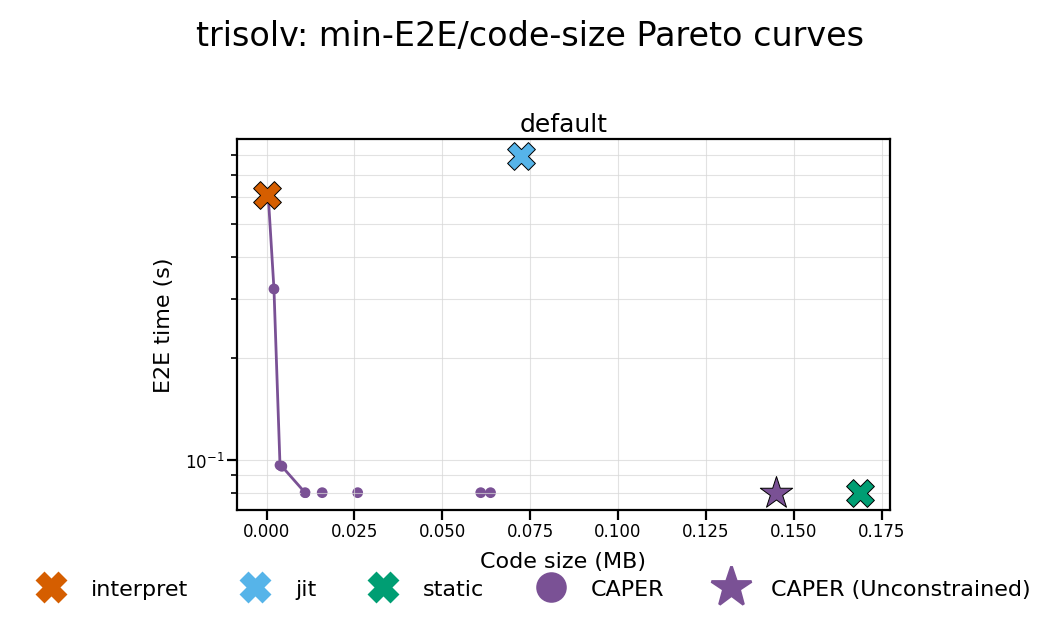

saved: evaluation/compilation-plan/out/pareto-curve.deriche-all-workloads.pdf


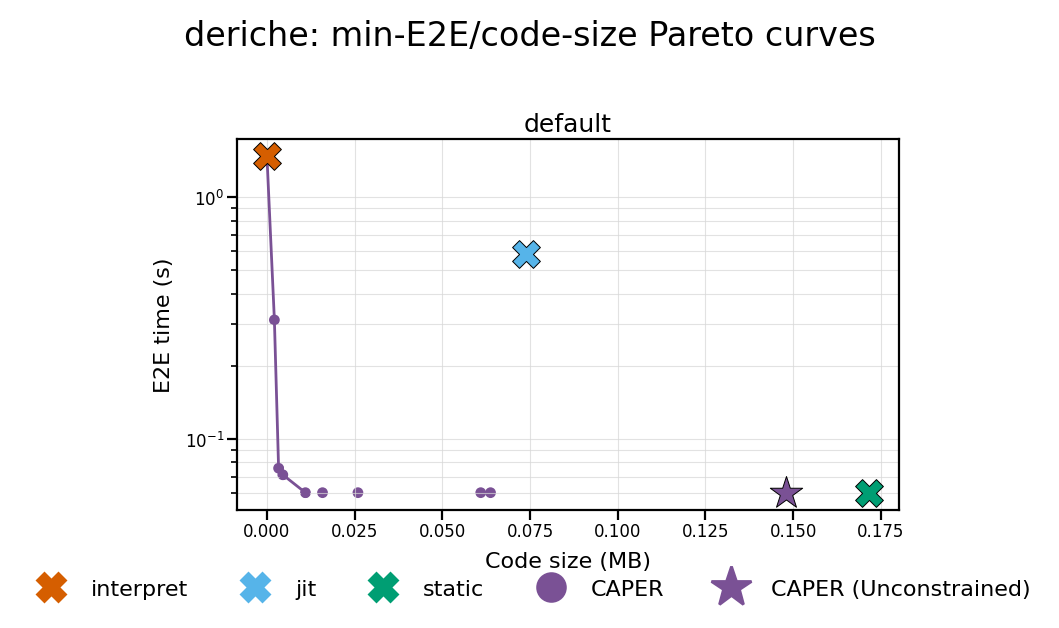

saved: evaluation/compilation-plan/out/pareto-curve.floyd-warshall-all-workloads.pdf


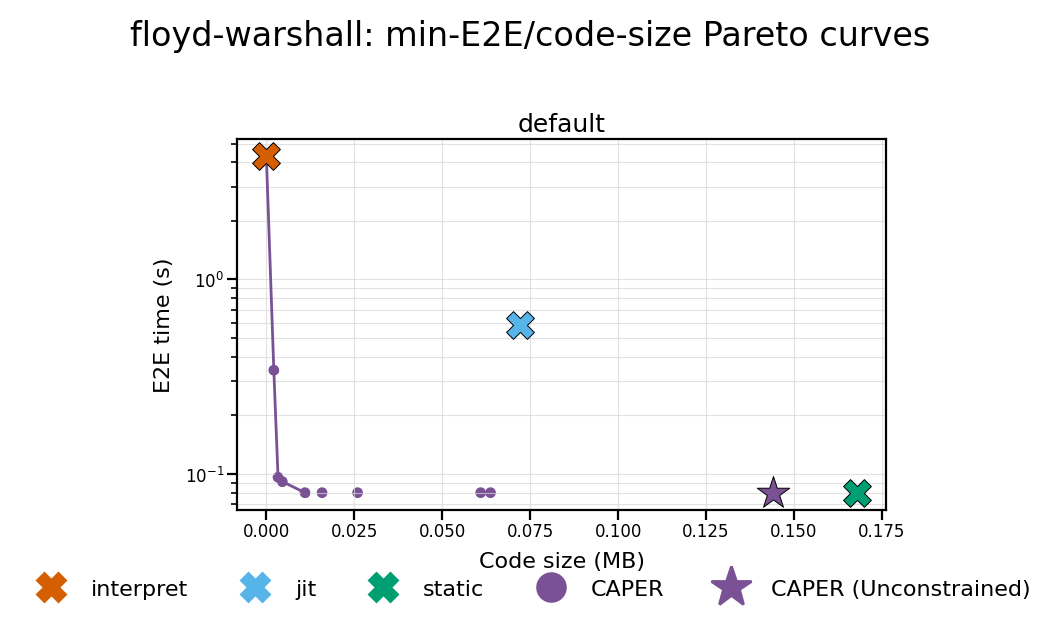

saved: evaluation/compilation-plan/out/pareto-curve.nussinov-all-workloads.pdf


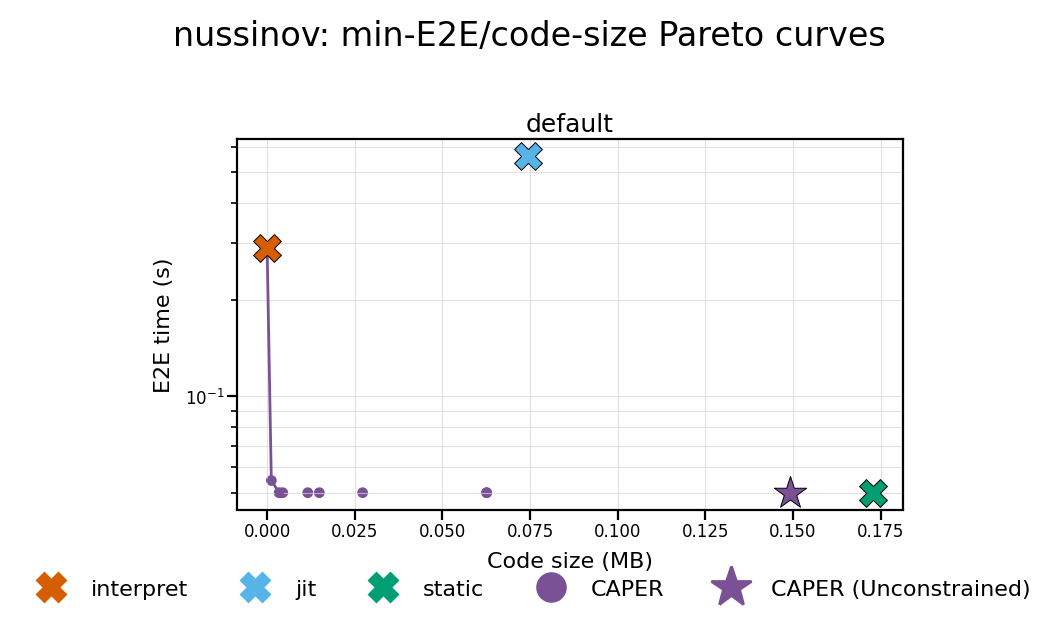

saved: evaluation/compilation-plan/out/pareto-curve.adi-all-workloads.pdf


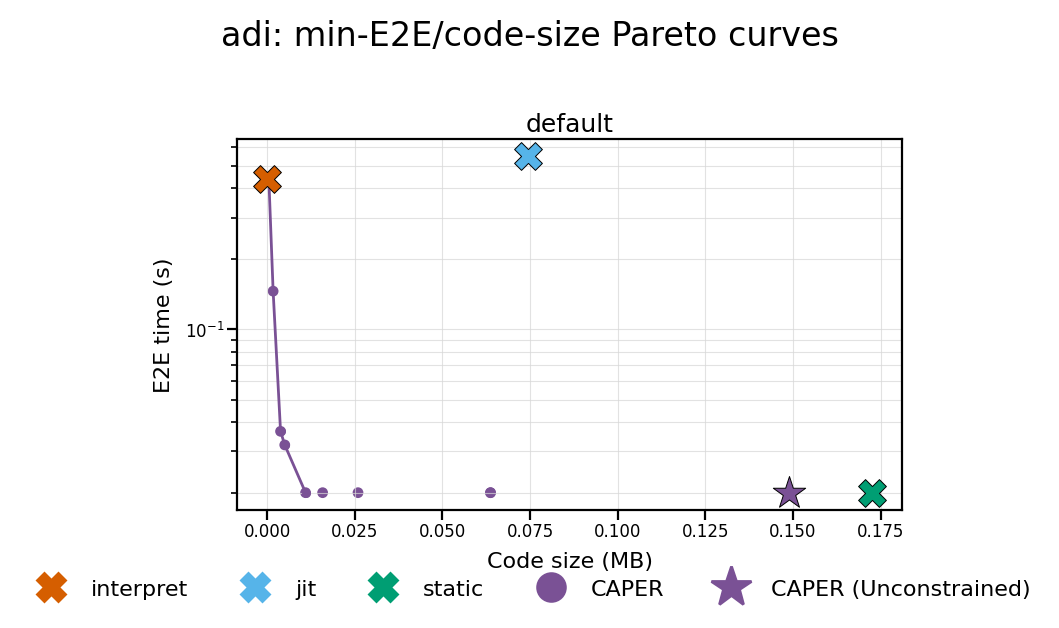

saved: evaluation/compilation-plan/out/pareto-curve.fdtd-2d-all-workloads.pdf


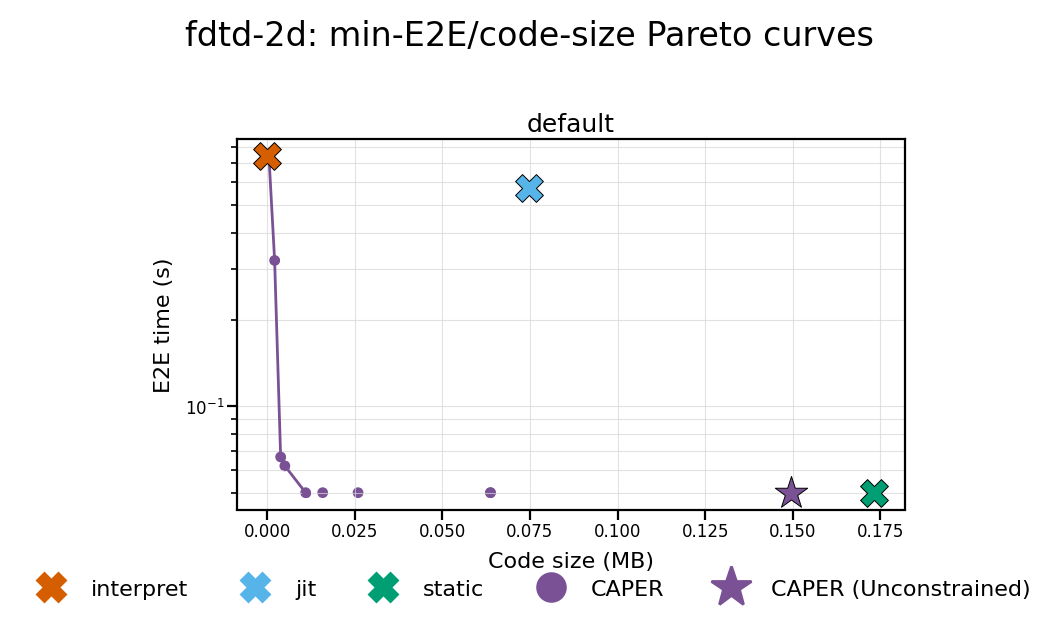

saved: evaluation/compilation-plan/out/pareto-curve.heat-3d-all-workloads.pdf


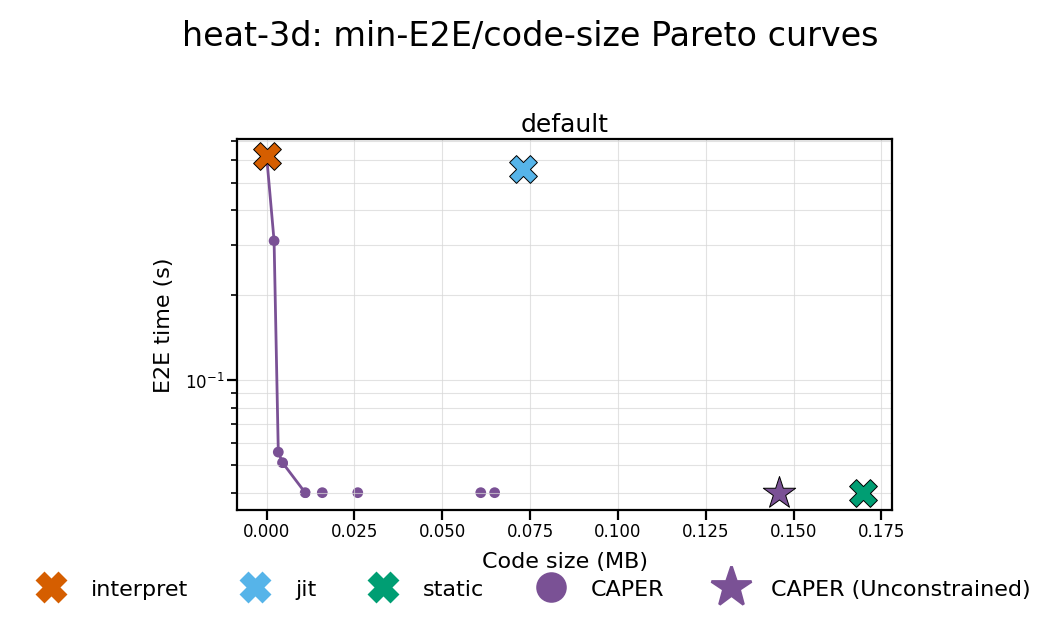

saved: evaluation/compilation-plan/out/pareto-curve.jacobi-1d-all-workloads.pdf


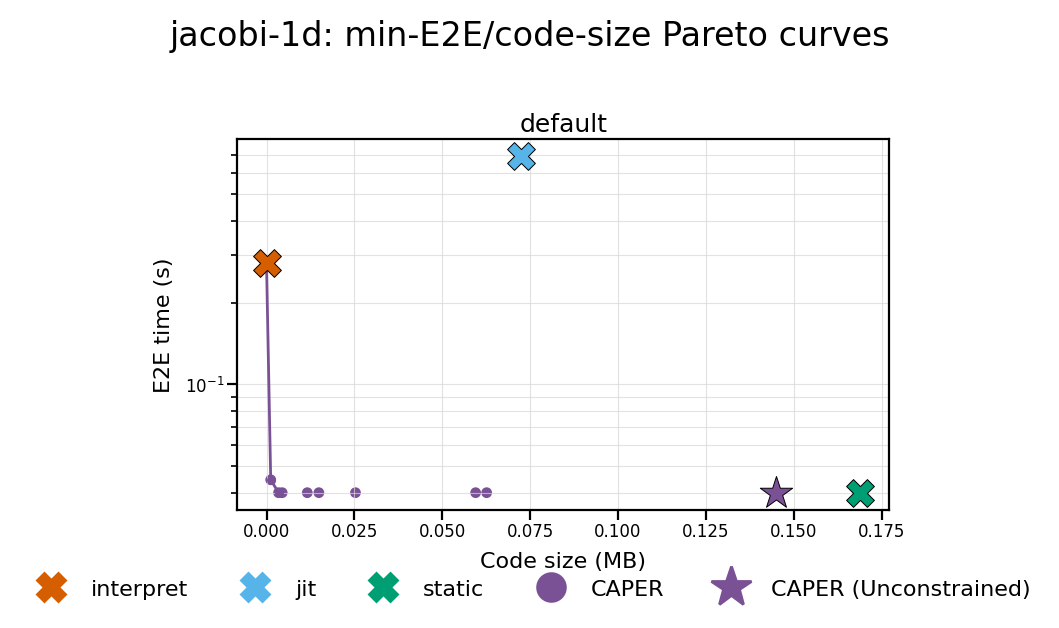

saved: evaluation/compilation-plan/out/pareto-curve.jacobi-2d-all-workloads.pdf


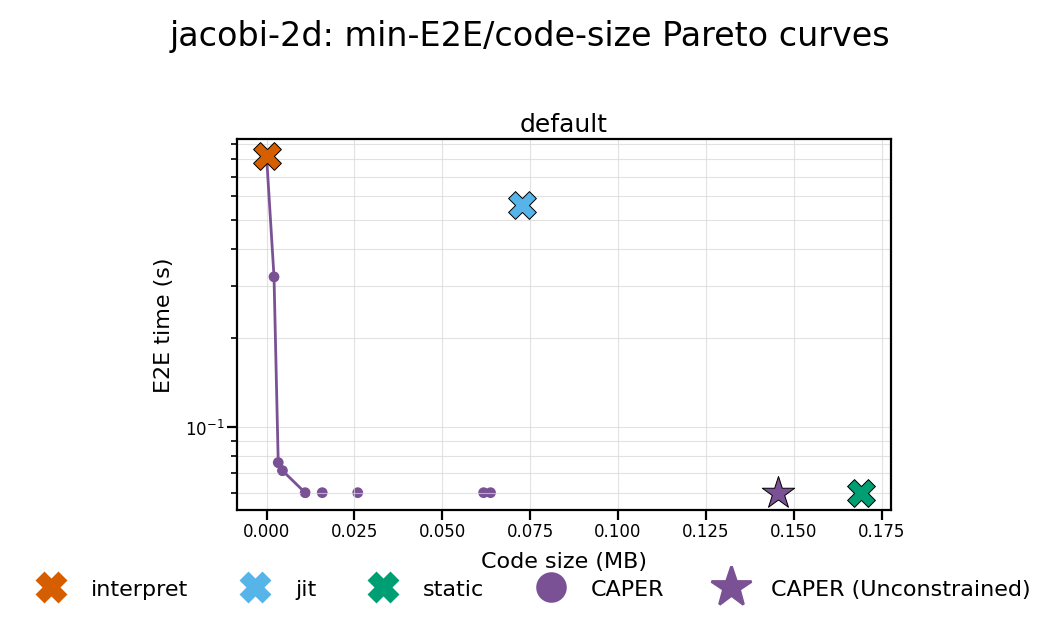

saved: evaluation/compilation-plan/out/pareto-curve.seidel-2d-all-workloads.pdf


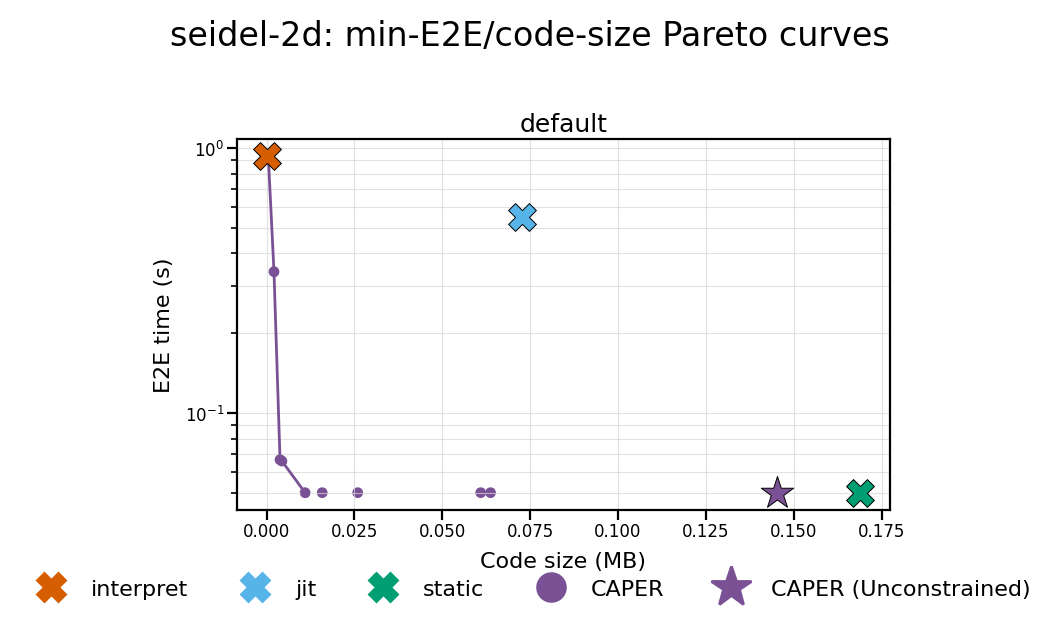

saved: evaluation/compilation-plan/out/pareto-curve.lbm-all-workloads.pdf


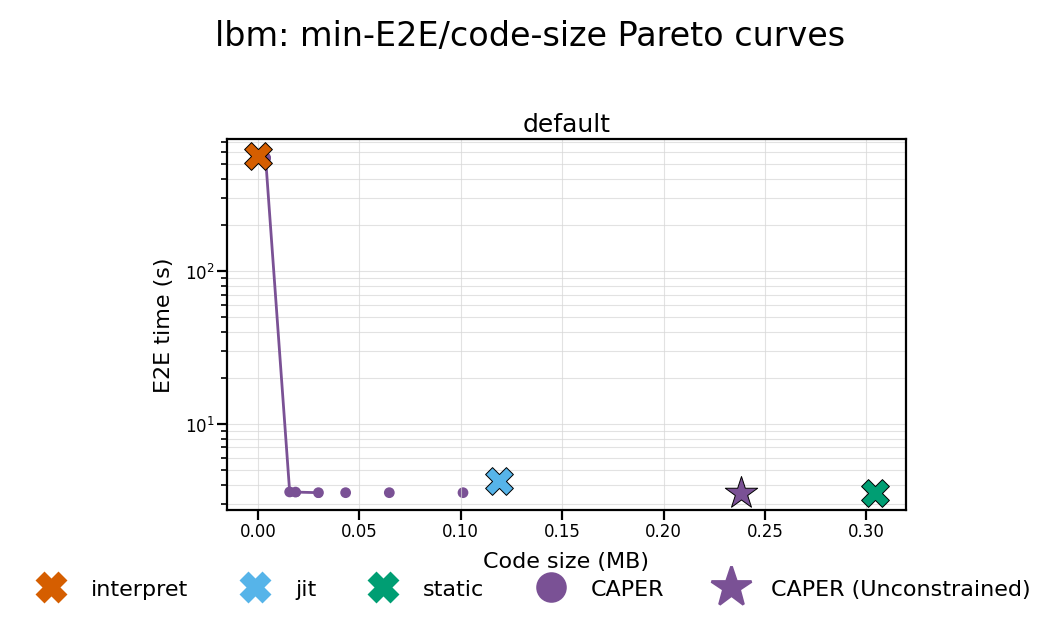

saved: evaluation/compilation-plan/out/pareto-curve.mcf-all-workloads.pdf


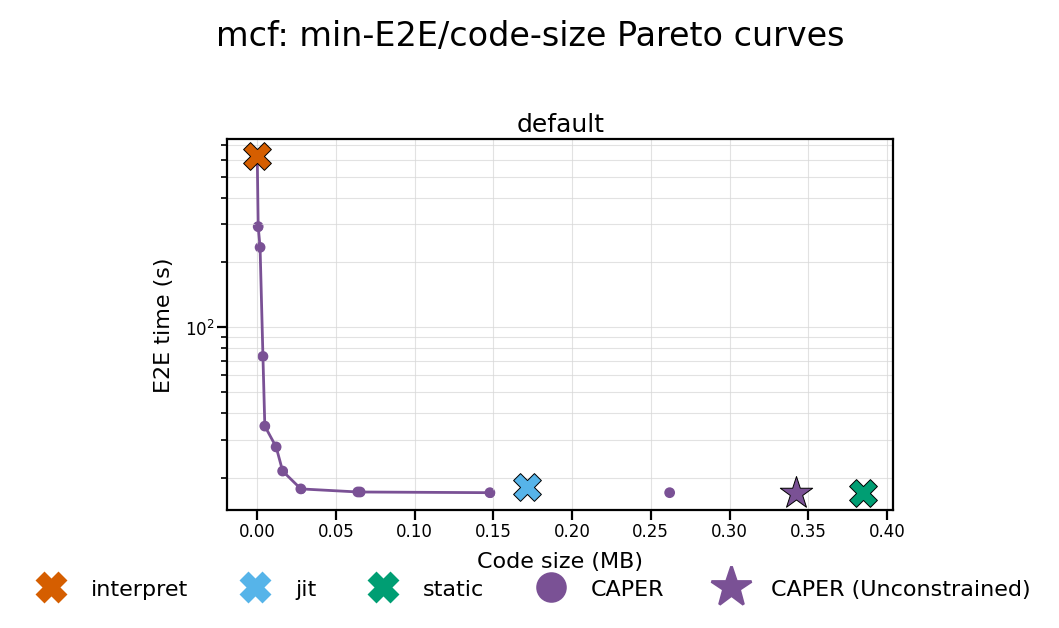

saved: evaluation/compilation-plan/out/pareto-curve.nab-all-workloads.pdf


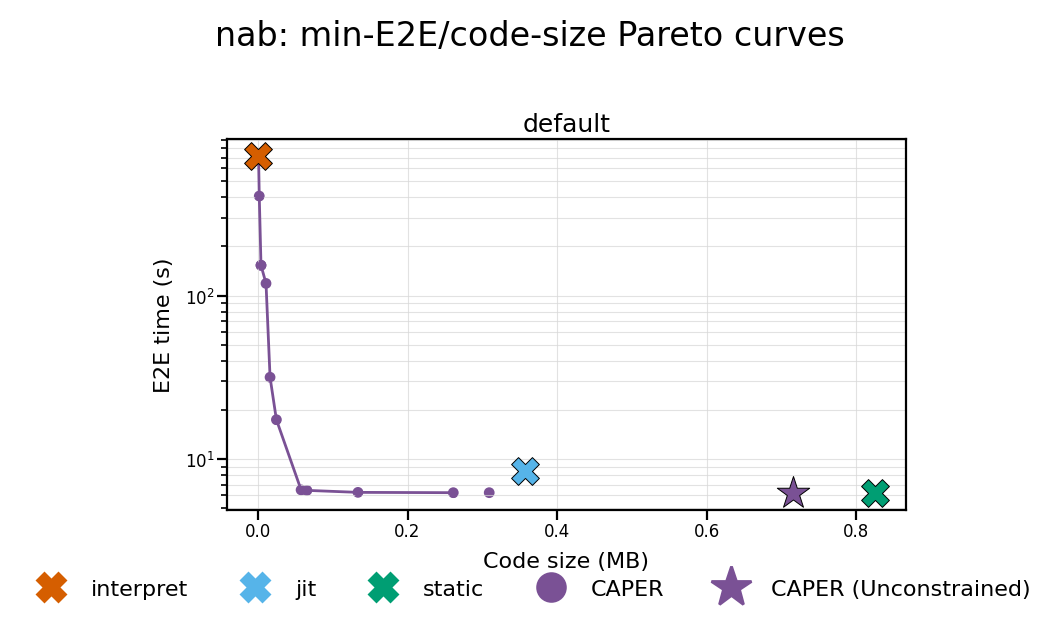

saved: evaluation/compilation-plan/out/pareto-curve.namd-all-workloads.pdf


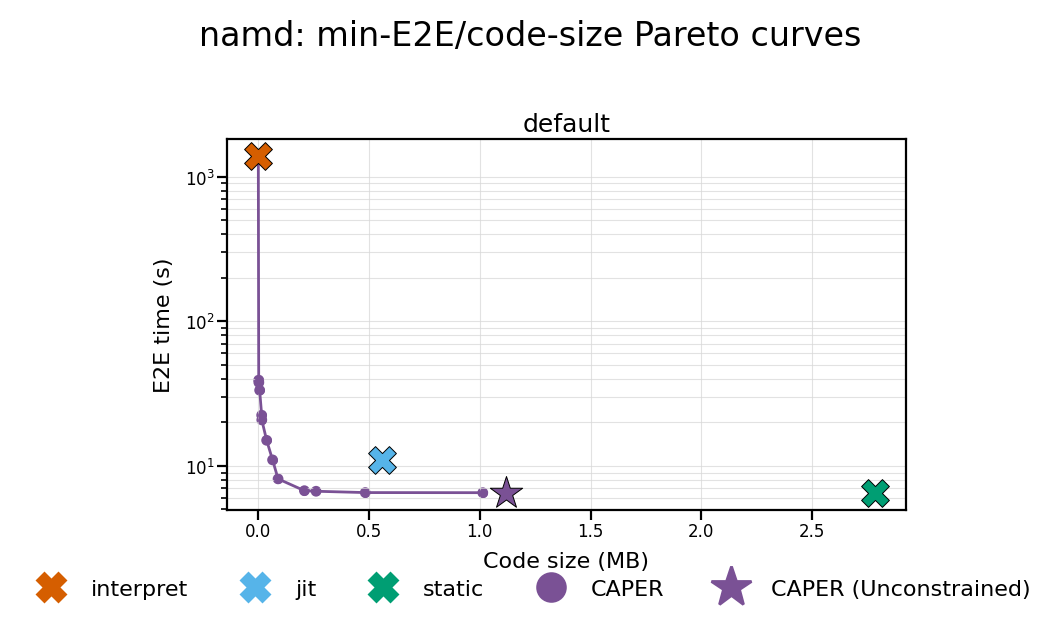

saved: evaluation/compilation-plan/out/pareto-curve.x264-all-workloads.pdf


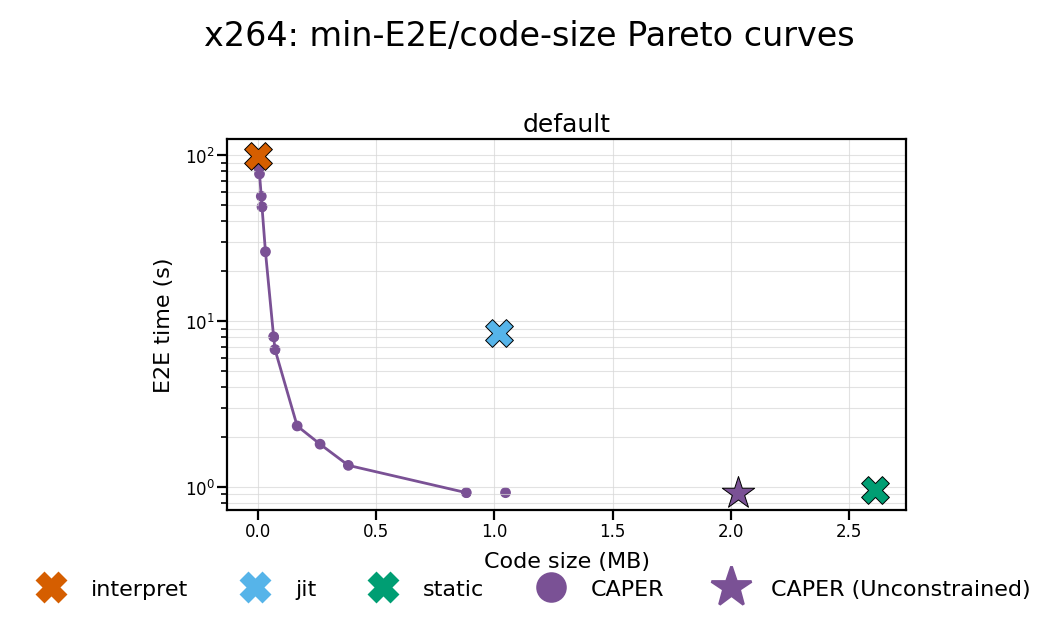

saved: evaluation/compilation-plan/out/pareto-curve.deepsjeng-all-workloads.pdf


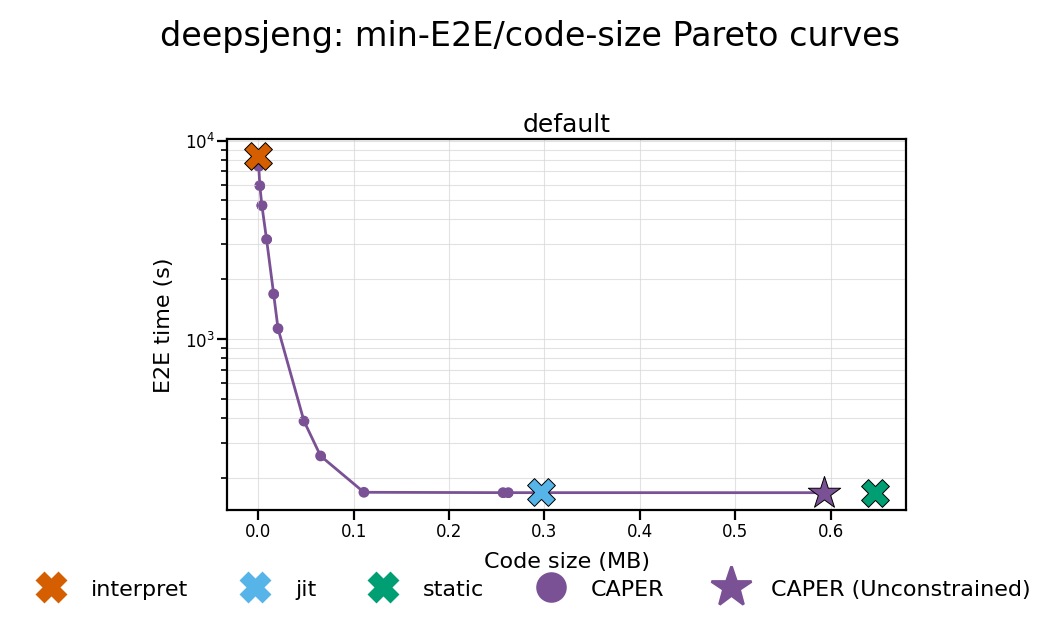

saved: evaluation/compilation-plan/out/pareto-curve.bzip2-all-workloads.pdf


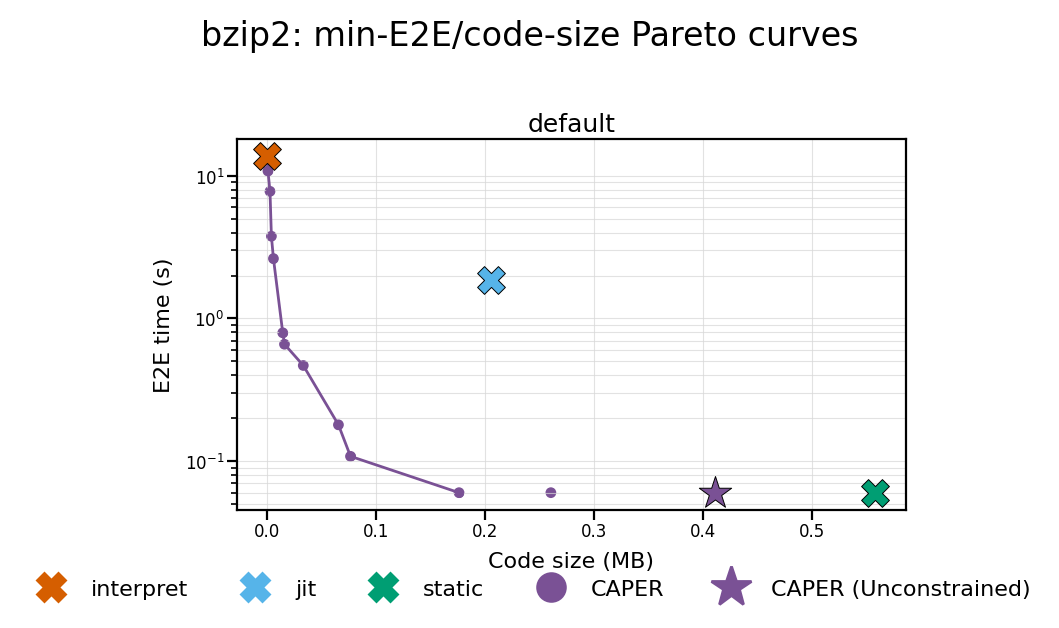

saved: evaluation/compilation-plan/out/pareto-curve.espeak-all-workloads.pdf


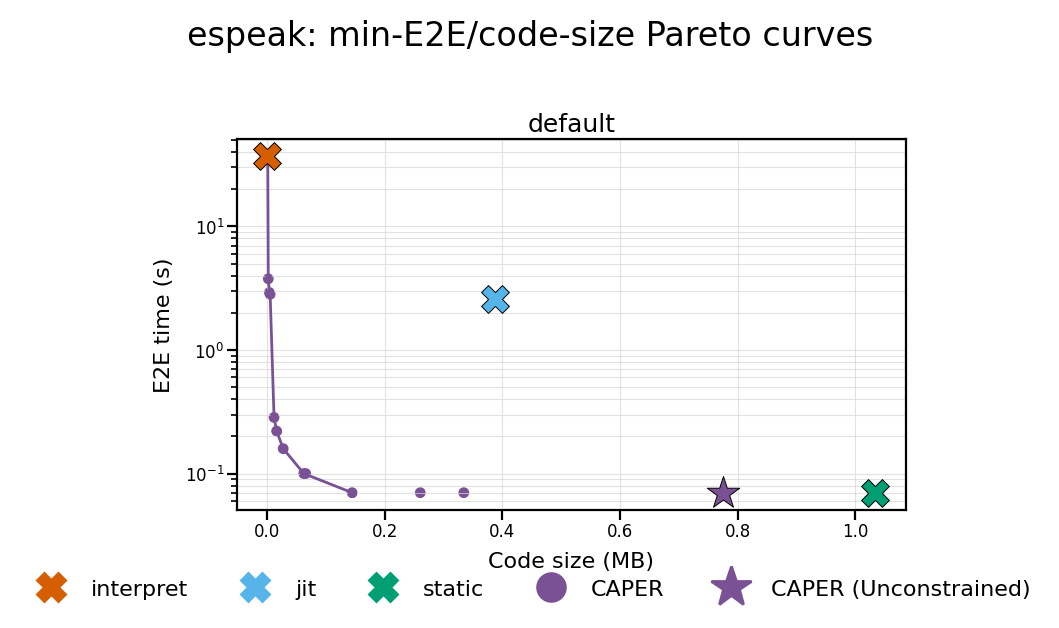

saved: evaluation/compilation-plan/out/pareto-curve.facedetection-all-workloads.pdf


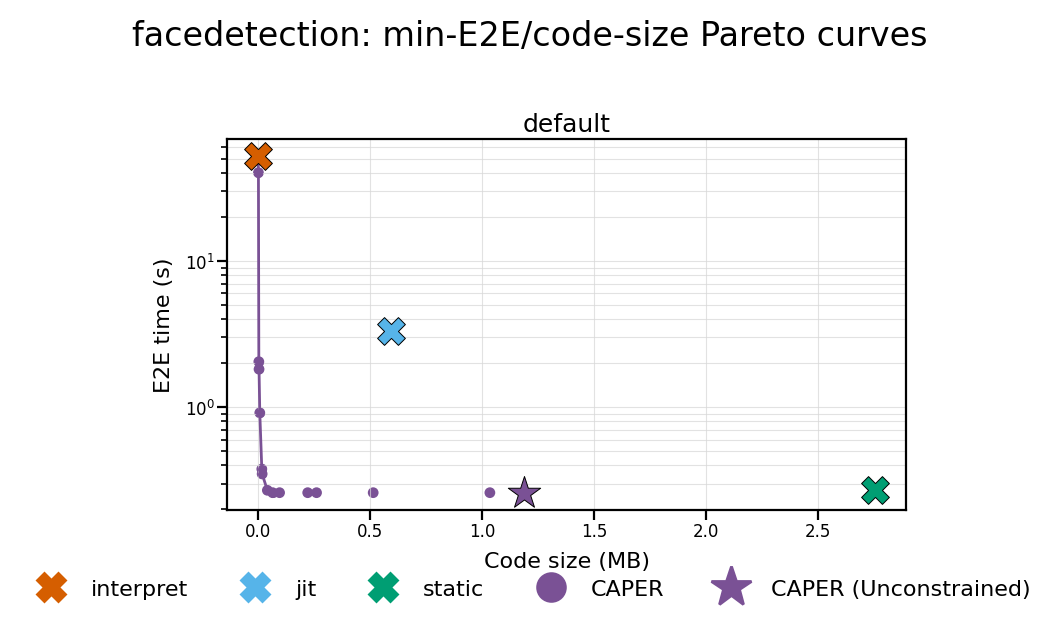

saved: evaluation/compilation-plan/out/pareto-curve.gnuchess-all-workloads.pdf


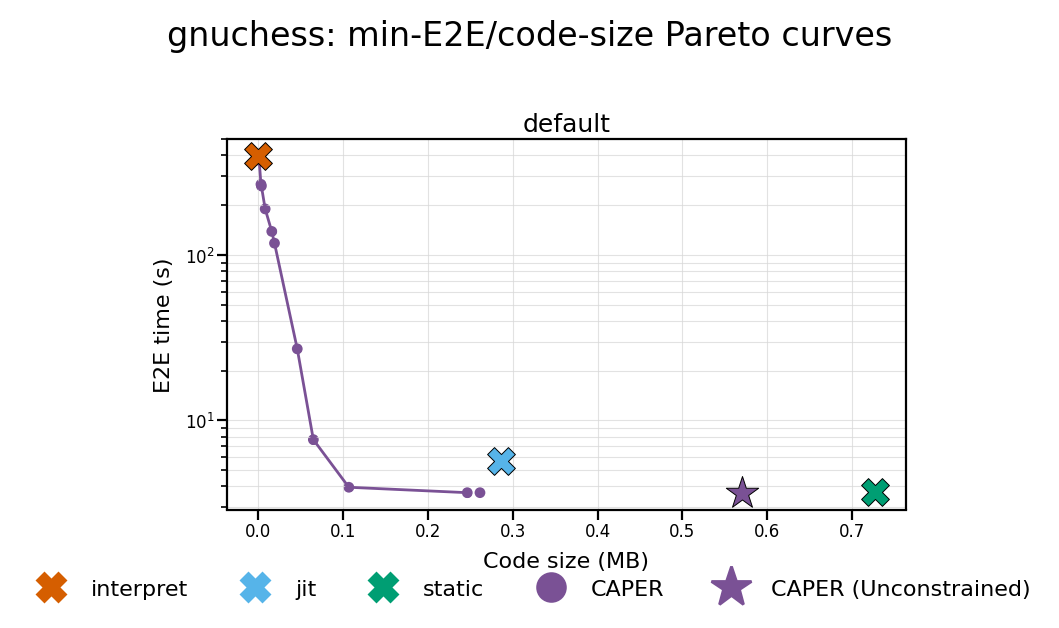

saved: evaluation/compilation-plan/out/pareto-curve.mnist-all-workloads.pdf


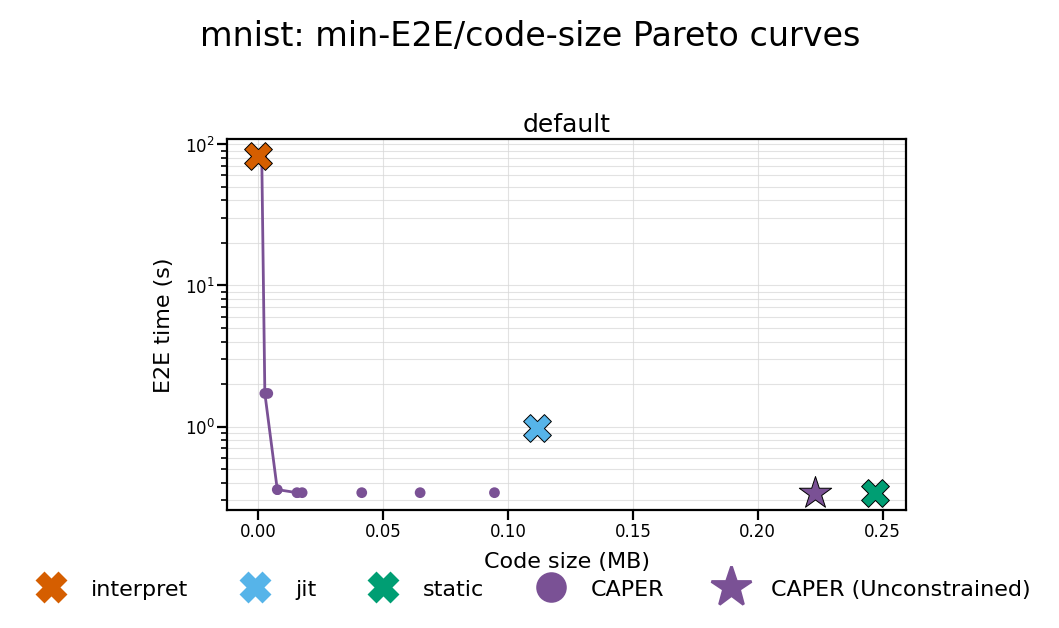

saved: evaluation/compilation-plan/out/pareto-curve.snappy-all-workloads.pdf


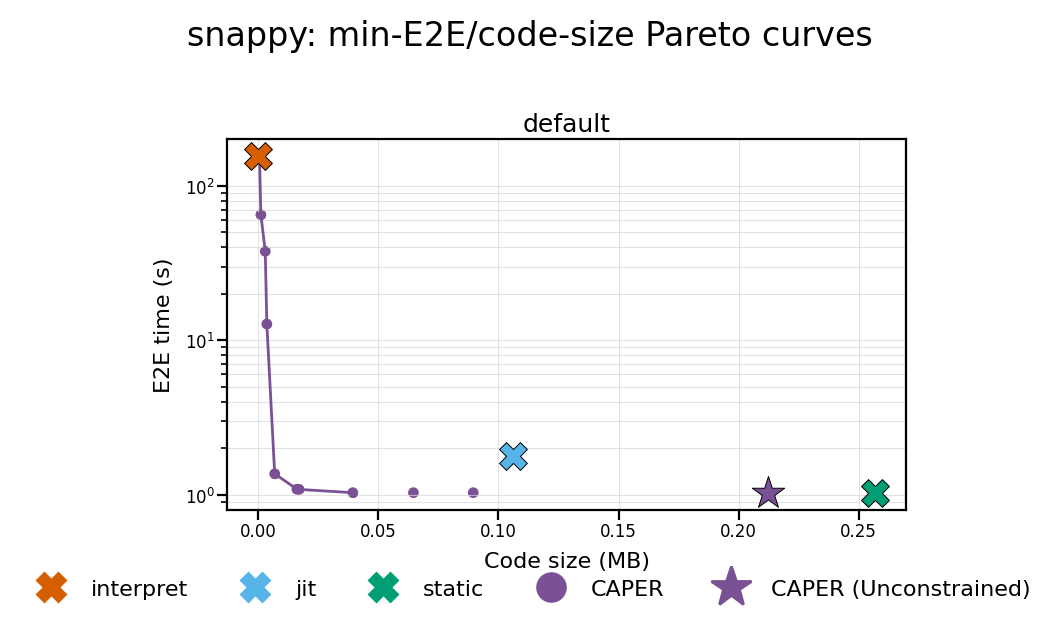

saved: evaluation/compilation-plan/out/pareto-curve.whitedb-all-workloads.pdf


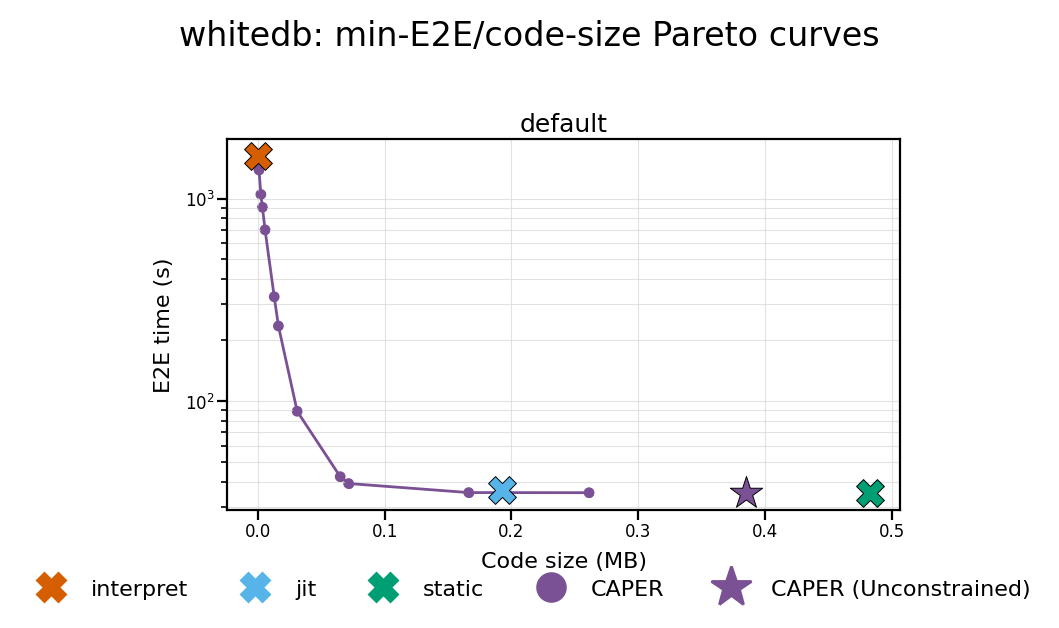

In [9]:
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
})

baseline_styles = {
    "interpret": ("#D55E00", "X", 100),
    "jit": ("#56B4E9", "X", 100),
    "static": ("#009E73", "X", 100),
    "unbounded min-E2E": ("#7A5195", "*", 150),
}

legend_handles = [
    Line2D([0], [0], marker="X", linestyle="none", markerfacecolor="#D55E00", markeredgecolor="#D55E00", markersize=10, label="interpret"),
    Line2D([0], [0], marker="X", linestyle="none", markerfacecolor="#56B4E9", markeredgecolor="#56B4E9", markersize=10, label="jit"),
    Line2D([0], [0], marker="X", linestyle="none", markerfacecolor="#009E73", markeredgecolor="#009E73", markersize=10, label="static"),
    Line2D([0], [0], marker="o", linestyle="none", color="#7A5195", markersize=10, label="CAPER"),
    Line2D([0], [0], marker="*", linestyle="none", markerfacecolor="#7A5195", markeredgecolor="#7A5195", markersize=15, label="CAPER (Unconstrained)"),
]

for benchmark in AVAILABLE_BENCHMARKS:
    results = all_results[benchmark.name]
    workloads = workloads_with_profile(benchmark)
    n = len(workloads)

    ncols = min(4, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), dpi=200, squeeze=False)

    for i, wl in enumerate(workloads):
        ax = axes.flat[i]
        wl_results = results[results["workload"] == wl.name].copy()
        sweep = wl_results[wl_results["label"] == "sweep"].copy()
        front = pareto_front(sweep)
        baselines = wl_results[wl_results["label"] != "sweep"].copy()

        ax.scatter(sweep["code_size_mb"], sweep["e2e_s"], s=15, color="#7A5195", edgecolor="none")
        ax.plot(front["code_size_mb"], front["e2e_s"], color="#7A5195", linewidth=1.0, marker="o", markersize=2.2)

        for _, row in baselines.iterrows():
            color, marker, size = baseline_styles[row["label"]]
            ax.scatter(row["code_size_mb"], row["e2e_s"], s=size, color=color, marker=marker,
                       edgecolor="black", linewidth=0.35, zorder=4)

        ax.set_title(wl.name, pad=3)
        ax.set_yscale("log")
        ax.grid(True, which="both", axis="both", color="#D7D7D7", linewidth=0.4, alpha=0.7)
        ax.tick_params(axis="both", which="major", labelsize=6, pad=1)

    for i in range(n, nrows * ncols):
        axes.flat[i].axis("off")

    for row_i in range(nrows):
        axes[row_i, 0].set_ylabel("E2E time (s)")
    for col_i in range(ncols):
        axes[-1, col_i].set_xlabel("Code size (MB)")

    fig.suptitle(f"{benchmark.name}: min-E2E/code-size Pareto curves", y=0.995, fontsize=12)
    fig.legend(handles=legend_handles, loc="lower center", ncols=6, frameon=False, bbox_to_anchor=(0.5, -0.005))
    fig.tight_layout(rect=[0, 0.035, 1, 0.975])

    plot_pdf = OUT_DIR / f"pareto-curve.{benchmark.name.lower()}-all-workloads.pdf"
    fig.savefig(plot_pdf, bbox_inches="tight")
    print(f"saved: {plot_pdf.relative_to(PROJECT_ROOT)}")
    plt.show()

In [7]:
# One subplot per workload across all benchmarks, 4 columns
all_workload_pairs = [
    (benchmark, wl)
    for benchmark in AVAILABLE_BENCHMARKS
    for wl in workloads_with_profile(benchmark)
]

ncols = 4
nrows = math.ceil(len(all_workload_pairs) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), dpi=320, squeeze=False)

for i, (benchmark, wl) in enumerate(all_workload_pairs):
    ax = axes.flat[i]
    results = all_results[benchmark.name]

    wl_results = results[results["workload"] == wl.name].copy()
    sweep = wl_results[wl_results["label"] == "sweep"].copy()
    front = pareto_front(sweep)
    baselines = wl_results[wl_results["label"] != "sweep"].copy()

    ax.scatter(sweep["code_size_mb"], sweep["e2e_s"],
               s=10, color="#7A5195", edgecolor="none")
    ax.plot(front["code_size_mb"], front["e2e_s"],
            color="#7A5195", linewidth=0.9, marker="o", markersize=2)

    for _, row in baselines.iterrows():
        color, marker, size = baseline_styles[row["label"]]
        ax.scatter(row["code_size_mb"], row["e2e_s"],
                   s=size * 0.6, color=color, marker=marker,
                   edgecolor="black", linewidth=0.25, zorder=4)

    # Use workload name for multi-workload benchmarks, benchmark name for single-workload.
    title = wl.name if len(benchmark.workloads) > 1 else benchmark.name
    ax.set_title(f"{title}", pad=3)
    ax.set_yscale("log")
    ax.grid(True, which="both", axis="both", color="#D7D7D7", linewidth=0.4, alpha=0.7)
    ax.tick_params(axis="both", which="major", labelsize=6, pad=1)

for i in range(len(all_workload_pairs), nrows * ncols):
    axes.flat[i].axis("off")

for row_i in range(nrows):
    axes[row_i, 0].set_ylabel("E2E time (s)")
for col_i in range(ncols):
    axes[-1, col_i].set_xlabel("Code size (MB)")

fig.suptitle("min-E2E / code-size Pareto curves — all benchmarks", y=0.999, fontsize=12)
fig.legend(handles=legend_handles, loc="lower center", ncols=6, frameon=False, bbox_to_anchor=(0.5, -0.005))
fig.tight_layout(rect=[0, 0.025, 1, 0.975])

plot_pdf = OUT_DIR / "pareto-curve.all-benchmarks.pdf"
fig.savefig(plot_pdf, bbox_inches="tight")
print(f"saved: {plot_pdf.relative_to(PROJECT_ROOT)}")
plt.show()

saved: evaluation/compilation-plan/out/pareto-curve.all-benchmarks.pdf


NameError: name 'baseline_styles' is not defined

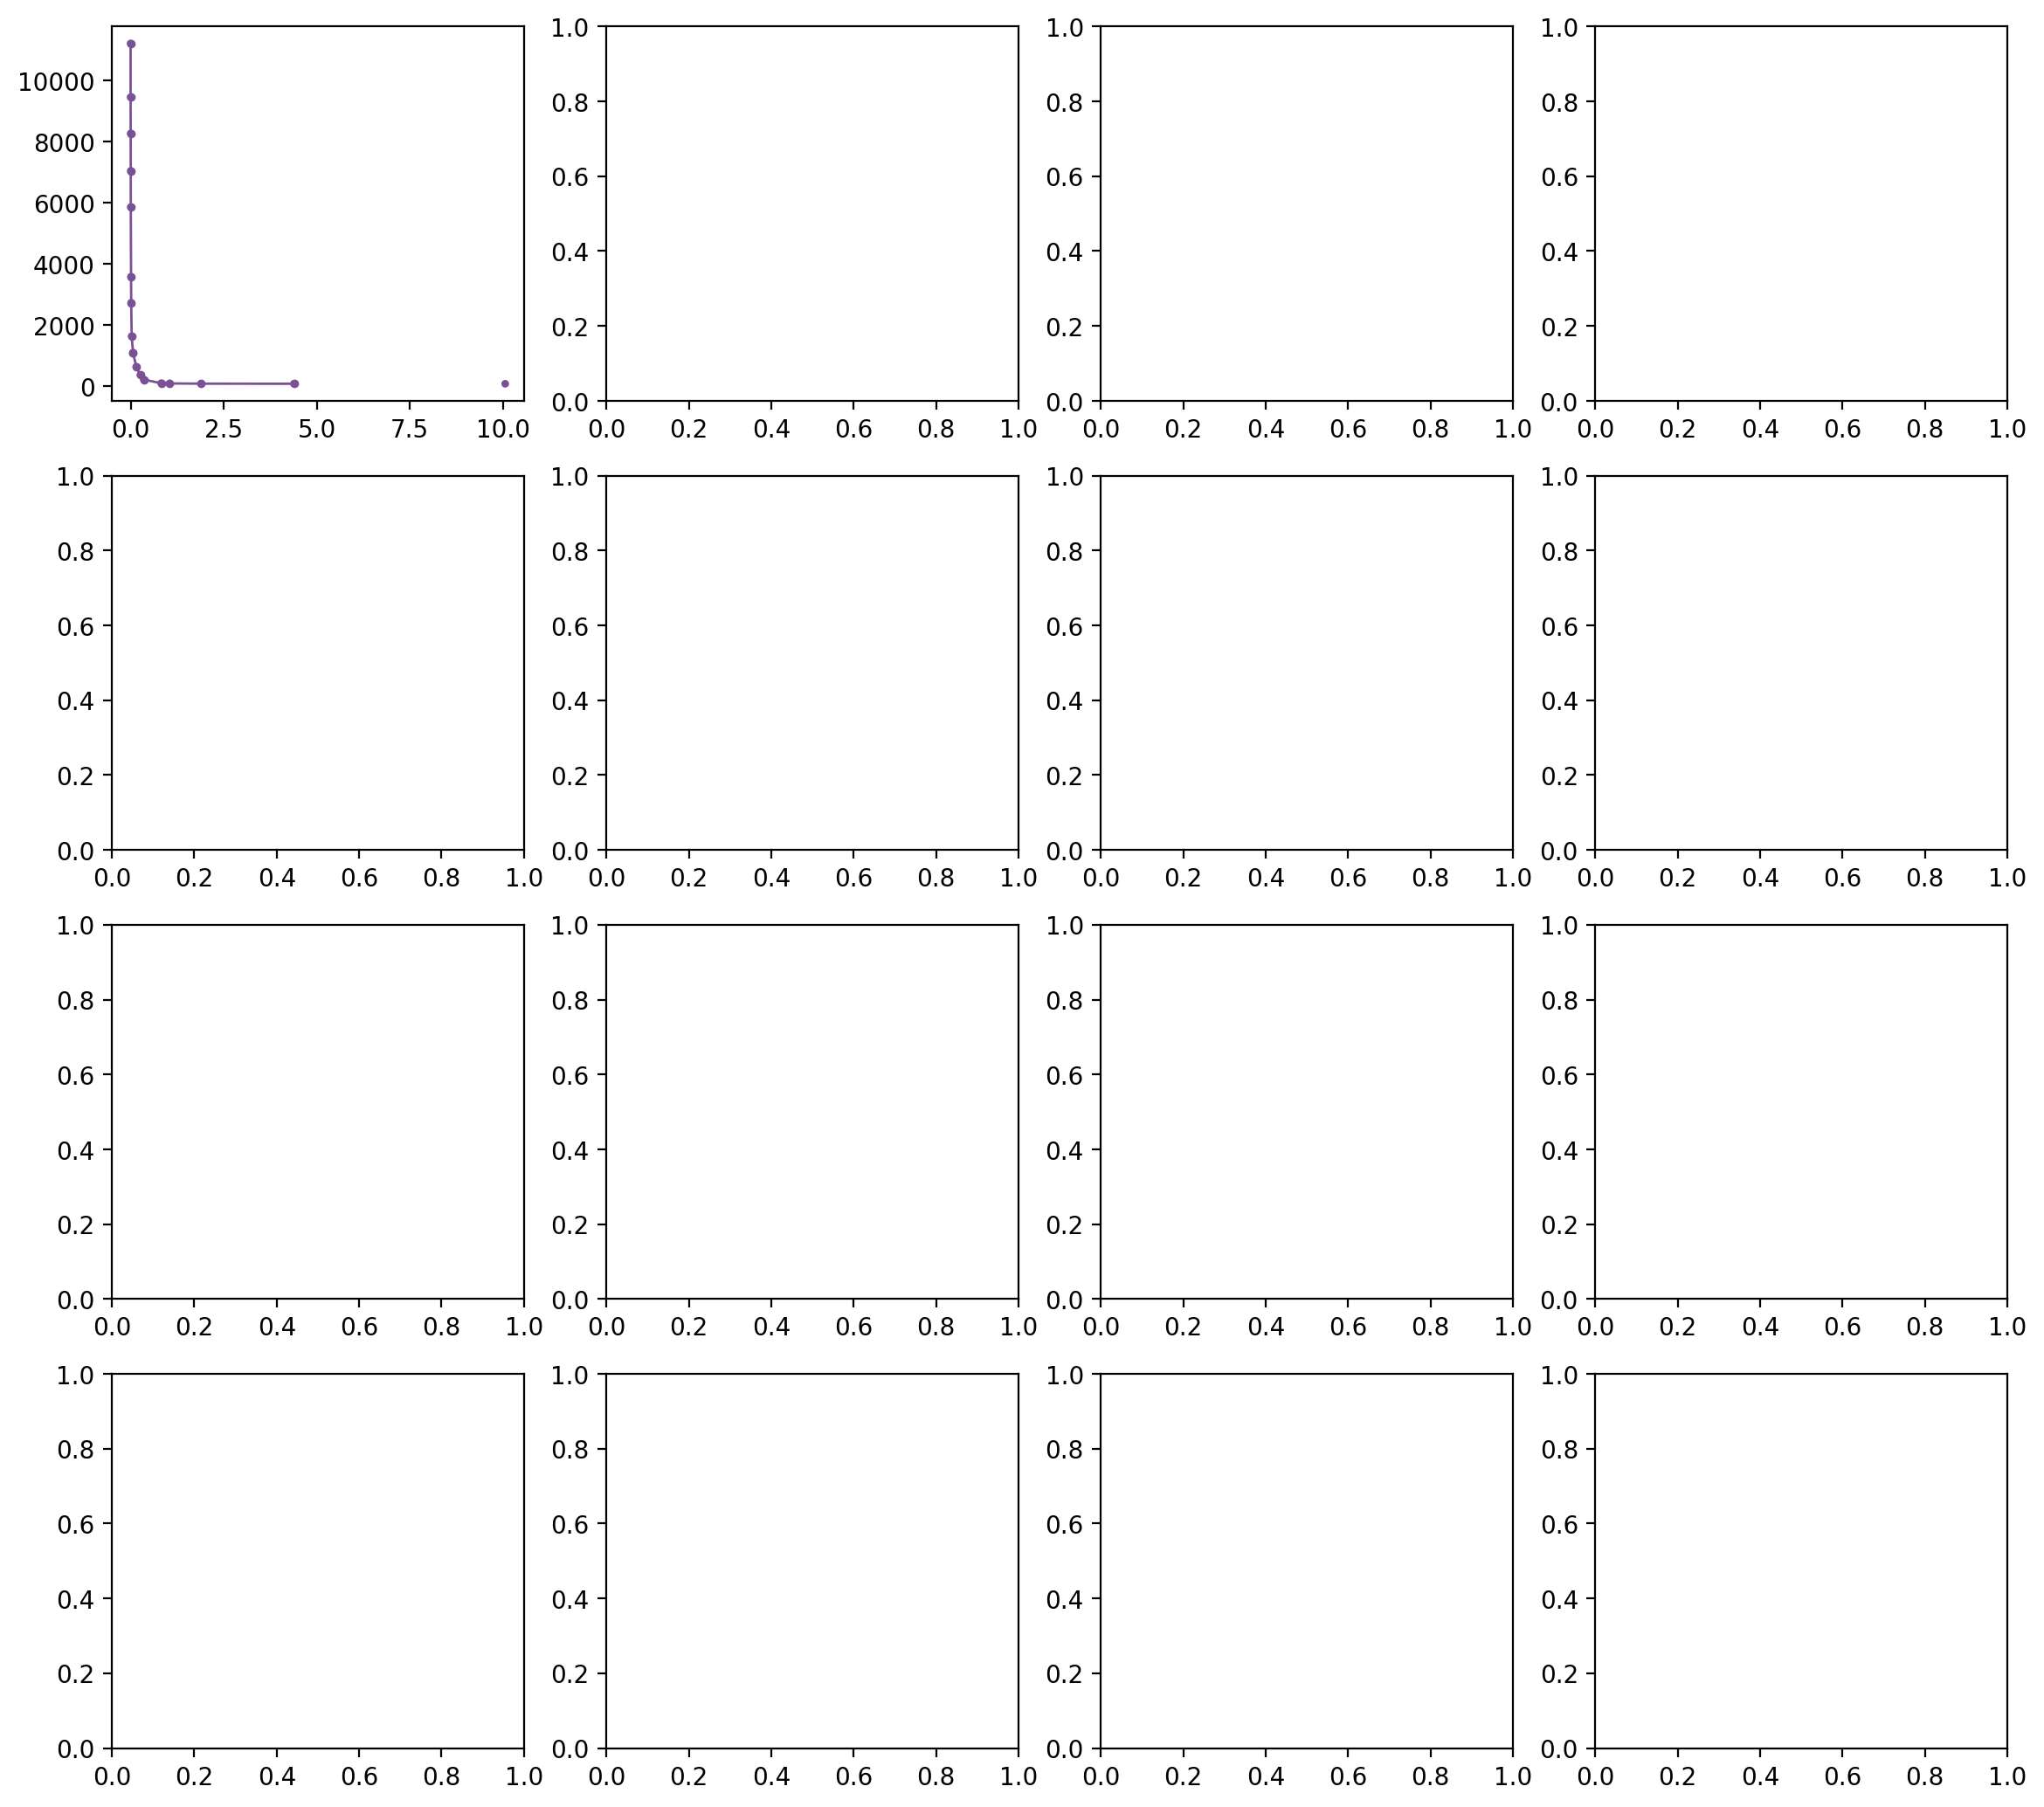

In [7]:
# Pairwise metric trade-offs: all (X, Y) combinations — lower-triangular grid.
# Shows that no single baseline dominates across all dimension pairs.

DEMO_BENCHMARK = next(b for b in AVAILABLE_BENCHMARKS if b.name == "FFmpeg")
DEMO_WORKLOAD  = workloads_with_profile(DEMO_BENCHMARK)[0]  # mov-to-mp4

results   = all_results[DEMO_BENCHMARK.name]
wl_data   = results[results["workload"] == DEMO_WORKLOAD.name].copy()
sweep     = wl_data[wl_data["label"] == "sweep"].copy()
baselines = wl_data[wl_data["label"] != "sweep"].copy()

NS = 1e9
for df in (sweep, baselines):
    for c in ("exec", "compilation", "waiting"):
        df[f"{c}_s"] = df[c] / NS

def pareto_front_2d(df, x_col, y_col):
    """Pareto front minimising both x_col and y_col simultaneously."""
    pts = df.sort_values([x_col, y_col]).copy()
    best, keep = float("inf"), []
    for _, row in pts.iterrows():
        if row[y_col] < best:
            keep.append(True)
            best = row[y_col]
        else:
            keep.append(False)
    return pts.loc[keep]

FLOOR = 1e-9  # prevents log(0) for zero-compilation/waiting points
metrics = [
    ("code_size_mb",  "Code size (MB)"),
    ("e2e_s",         "E2E time (s)"),
    ("exec_s",        "Exec time (s)"),
    ("compilation_s", "Compilation time (s)"),
    ("waiting_s",     "Startup wait (s)"),
]
n = len(metrics)

fig, axes = plt.subplots(n - 1, n - 1,
                         figsize=(3.5 * (n - 1), 3.2 * (n - 1)),
                         dpi=200, squeeze=False)

for row_i in range(1, n):       # y-axis metric
    for col_i in range(n - 1):  # x-axis metric
        ax = axes[row_i - 1, col_i]
        if col_i >= row_i:
            ax.axis("off")
            continue

        x_col, x_label = metrics[col_i]
        y_col, y_label = metrics[row_i]
        front = pareto_front_2d(sweep, x_col, y_col)

        ax.scatter(sweep[x_col].clip(lower=FLOOR), sweep[y_col].clip(lower=FLOOR),
                   s=10, color="#7A5195", edgecolor="none", zorder=2)
        ax.plot(front[x_col].clip(lower=FLOOR), front[y_col].clip(lower=FLOOR),
                color="#7A5195", linewidth=1.0, marker="o", markersize=2.5, zorder=3)

        for _, row in baselines.iterrows():
            color, marker, size = baseline_styles[row["label"]]
            ax.scatter(max(row[x_col], FLOOR), max(row[y_col], FLOOR),
                       s=size * 0.6, color=color, marker=marker,
                       edgecolor="black", linewidth=0.3, zorder=4)

        ax.set_xlabel(x_label, fontsize=7)
        ax.set_ylabel(y_label, fontsize=7)
        # ax.set_xscale("log")
        # ax.set_yscale("log")
        ax.grid(True, which="both", color="#D7D7D7", linewidth=0.4, alpha=0.7)
        ax.tick_params(axis="both", labelsize=6)

fig.suptitle(
    f"FFmpeg · {DEMO_WORKLOAD.name}: pairwise metric trade-offs",
    fontsize=11, y=1.01,
)
fig.legend(handles=legend_handles, loc="lower center", ncols=5, frameon=False,
           bbox_to_anchor=(0.5, -0.04))
fig.tight_layout()

plot_pdf = OUT_DIR / f"pareto-curve.multidim.{DEMO_WORKLOAD.name}.pdf"
fig.savefig(plot_pdf, bbox_inches="tight")
print(f"saved: {plot_pdf.relative_to(PROJECT_ROOT)}")
plt.show()

In [ ]:
import zipfile

MULTIDIM_DIR = OUT_DIR / "multidim"
MULTIDIM_DIR.mkdir(exist_ok=True)

for benchmark in AVAILABLE_BENCHMARKS:
    results = all_results[benchmark.name]
    for wl in workloads_with_profile(benchmark):
        wl_data   = results[results["workload"] == wl.name].copy()
        sweep     = wl_data[wl_data["label"] == "sweep"].copy()
        baselines = wl_data[wl_data["label"] != "sweep"].copy()

        for df in (sweep, baselines):
            for c in ("exec", "compilation", "waiting"):
                df[f"{c}_s"] = df[c] / NS

        fig, axes = plt.subplots(n - 1, n - 1,
                                 figsize=(3.5 * (n - 1), 3.2 * (n - 1)),
                                 dpi=200, squeeze=False)

        for row_i in range(1, n):
            for col_i in range(n - 1):
                ax = axes[row_i - 1, col_i]
                if col_i >= row_i:
                    ax.axis("off")
                    continue

                x_col, x_label = metrics[col_i]
                y_col, y_label = metrics[row_i]
                front = pareto_front_2d(sweep, x_col, y_col)

                ax.scatter(sweep[x_col].clip(lower=FLOOR), sweep[y_col].clip(lower=FLOOR),
                           s=10, color="#7A5195", edgecolor="none", zorder=2)
                ax.plot(front[x_col].clip(lower=FLOOR), front[y_col].clip(lower=FLOOR),
                        color="#7A5195", linewidth=1.0, marker="o", markersize=2.5, zorder=3)

                for _, row in baselines.iterrows():
                    color, marker, size = baseline_styles[row["label"]]
                    ax.scatter(max(row[x_col], FLOOR), max(row[y_col], FLOOR),
                               s=size * 0.6, color=color, marker=marker,
                               edgecolor="black", linewidth=0.3, zorder=4)

                ax.set_xlabel(x_label, fontsize=7)
                ax.set_ylabel(y_label, fontsize=7)
                # ax.set_xscale("log")
                # ax.set_yscale("log")
                ax.grid(True, which="both", color="#D7D7D7", linewidth=0.4, alpha=0.7)
                ax.tick_params(axis="both", labelsize=6)

        title = wl.name if len(benchmark.workloads) > 1 else benchmark.name
        fig.suptitle(f"{benchmark.name} · {title}: pairwise metric trade-offs",
                     fontsize=11, y=1.01)
        fig.legend(handles=legend_handles, loc="lower center", ncols=5, frameon=False,
                   bbox_to_anchor=(0.5, -0.04))
        fig.tight_layout()

        slug = f"{benchmark.name.lower()}-{wl.name}"
        plot_pdf = MULTIDIM_DIR / f"pareto-curve.multidim.{slug}.pdf"
        fig.savefig(plot_pdf, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"saved: {plot_pdf.name}")

# Bundle all PDFs into a single zip for download
zip_path = OUT_DIR / "pareto-curve.multidim.all.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for pdf in sorted(MULTIDIM_DIR.glob("*.pdf")):
        zf.write(pdf, pdf.name)
print(f"\nzip: {zip_path.relative_to(PROJECT_ROOT)}  ({zip_path.stat().st_size / 1e6:.1f} MB)")